<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%209/W09_L2_Transformers_for_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=9lP99tPLCRw) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%209/NPTEL_Jul24_DL4CV_W09_P02.pdf)

In [1]:
# Week 9, Lecture 2: Transformers for Detection
from IPython.display import HTML, display

VIDEO_ID = "9lP99tPLCRw"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 9, Lecture 2: Transformers for Detection

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§9.2 Transformers for Detection**.

This notebook builds a working **DETR** from its parts (boxes and generalized IoU, a 2D sinusoidal positional encoding, a transformer encoder-decoder, object queries, bipartite matching and the Hungarian loss), trains it on a synthetic shape-detection dataset in about a minute, measures the limitations the slides list, and then implements the two ideas that fix them: **deformable attention** and **denoising queries**.

**What you will learn**
- Detection as **direct set prediction**: $N$ parallel predictions, a "no object" class $\varnothing$, no anchors and no non-maximum suppression.
- **Generalized IoU**, $\mathrm{GIoU} = \mathrm{IoU} - \frac{|C \setminus (A \cup B)|}{|C|}$, why it is scale-invariant where $L_1$ is not, and how it stays informative when boxes do not overlap.
- **Bipartite matching**: $\hat\sigma = \arg\min_{\sigma \in S_N} \sum_i \mathcal{L}_{\mathrm{match}}(y_i, \hat y_{\sigma(i)})$, solved by brute force on a tiny case and by the **Hungarian algorithm** in general.
- The **Hungarian loss** $\mathcal{L}_{\mathrm{Hungarian}} = \sum_i \left[-\log \hat p_{\hat\sigma(i)}(c_i) + \mathbb{1}_{\{c_i \neq \varnothing\}} \mathcal{L}_{\mathrm{box}}(b_i, \hat b_{\hat\sigma(i)})\right]$ with $\mathcal{L}_{\mathrm{box}} = \lambda_{\mathrm{iou}} \mathcal{L}_{\mathrm{iou}} + \lambda_{L1} \|b_i - \hat b_{\hat\sigma(i)}\|_1$.
- **Object queries** and what they learn: per-query spatial specialization and decoder cross-attention maps.
- DETR's three limitations, measured: quadratic attention cost, near-uniform $1/N_k$ attention at initialization, and weaker performance on small objects.
- **Deformable attention**, $\mathrm{DeformAttn}(z_q, p_q, x) = \sum_m W_m \sum_k A_{mqk} W'_m\, x(p_q + \Delta p_{mqk})$, built with `grid_sample`, single- and multi-scale, with its cost compared against dense attention.
- **DINO**: denoising training (implemented and measured), contrastive denoising, mixed query selection and look forward twice.

**Contents**

0. A synthetic detection dataset
1. Boxes, IoU and generalized IoU
2. The DETR architecture
3. Bipartite matching
4. The Hungarian loss
5. Training the tiny DETR
6. What the object queries learned
7. Limitations of DETR, measured
8. Deformable DETR: deformable attention
9. DINO: denoising anchor boxes
10. Explore and verify

**How to run**  Everything is tiny and runs in a few minutes on **Colab CPU or GPU** (no GPU needed). Run the setup cell first, then go top to bottom. Each of the two training runs takes about a minute on CPU and is split over two cells of half the steps each, so no single cell runs for long.

## Review

The previous lecture followed transformers from NLP into vision: self-attention lets every token look at every other token, and the Vision Transformer (ViT) showed that a plain transformer over image patches, with a positional encoding to restore spatial information, can match CNNs on ImageNet classification. The slides for this lecture open with the same recall, and then turn to a harder task. Object detection has to localize and classify a variable number of objects, and the classical detectors of Week 6 (Faster R-CNN, FPN) did it with hand-crafted components: anchor boxes, heuristic assignment of anchors to ground truth, and non-maximum suppression to remove duplicates. The question this lecture answers is whether a transformer can do detection **end to end**, predicting a set of boxes directly, with none of those components. DETR says yes, and the rest of the lecture is about making DETR cheaper, faster to train, and better on small objects.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import sys, math, time, itertools
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import linear_sum_assignment
from torchvision.ops import box_iou, generalized_box_iou

# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed

def set_seed(seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
set_seed(0)

# Device: this line works unchanged on CPU and GPU runtimes.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_num_threads(min(4, torch.get_num_threads()))     # keep CPU runtime predictable on Colab
torch.set_printoptions(precision=4, sci_mode=False)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['image.interpolation'] = 'nearest'

def count_params(m):
    return sum(p.numel() for p in m.parameters())

print('torch', torch.__version__, '| device:', device)

torch 2.8.0 | device: cpu


## 0. A synthetic detection dataset

Every experiment in this notebook runs on one dataset that we generate ourselves, so that training finishes in seconds and the ground truth is exact. Each $48 \times 48$ image has a dark, slightly noisy background and **one to three shapes** that do not overlap:

| class id | shape | box |
|---|---|---|
| 0 | disk | tight box around the circle |
| 1 | square | the square itself |
| 2 | triangle | tight box around the triangle |

Three details are deliberate:

- **Color carries no class information.** Each shape gets a random bright color, so the detector has to read the shape, not the hue.
- **Sizes vary by a factor of 2.5** (half-width between 4 and 10 pixels), which gives us small and large objects to compare in section 7.
- **Boxes are stored as $(c_x, c_y, w, h)$ normalized to $[0, 1]$**, exactly the slide's $b_i \in [0,1]^4$. This is the format DETR predicts through a sigmoid; the corner format $(x_0, y_0, x_1, y_1)$ is used only to compute IoU.

In [3]:
IMG = 48
CLASS_NAMES = ['disk', 'square', 'triangle']
K = len(CLASS_NAMES)                     # number of real classes; class index K will mean "no object"
NO_OBJ = K

def make_sample(rng, H=IMG, n_range=(1, 3)):
    '''One image (3,H,H) in [0,1], boxes (n,4) as normalized (cx,cy,w,h), labels (n,).'''
    img = rng.uniform(0.05, 0.20, size=(3, 1, 1)).astype(np.float32) * np.ones((3, H, H), np.float32)
    img += rng.normal(0, 0.02, size=img.shape).astype(np.float32)
    yy, xx = np.mgrid[0:H, 0:H].astype(np.float32) + 0.5          # pixel centres
    boxes, labels, placed = [], [], []
    n = int(rng.integers(n_range[0], n_range[1] + 1))
    tries = 0
    while len(boxes) < n and tries < 50:
        tries += 1
        r = rng.uniform(4.0, 10.0)                                  # half-width in pixels
        cy, cx = rng.uniform(r + 1, H - r - 1, size=2)
        if any(abs(cy - py) < r + pr + 1 and abs(cx - px) < r + pr + 1 for (py, px, pr) in placed):
            continue                                                # reject overlaps
        kind = int(rng.integers(0, K))
        if kind == 0:
            m = (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2
        elif kind == 1:
            m = (np.abs(yy - cy) <= r) & (np.abs(xx - cx) <= r)
        else:
            m = (yy >= cy - r) & (yy <= cy + r) & (np.abs(xx - cx) <= (yy - (cy - r)) / 2.0)
        color = rng.uniform(0.45, 1.0, size=3).astype(np.float32)   # bright, class-independent
        color[rng.integers(0, 3)] = rng.uniform(0.0, 0.3)
        img[:, m] = color[:, None]
        ys, xs = np.where(m)
        x0, x1, y0, y1 = xs.min(), xs.max() + 1, ys.min(), ys.max() + 1
        boxes.append([(x0 + x1) / 2 / H, (y0 + y1) / 2 / H, (x1 - x0) / H, (y1 - y0) / H])
        labels.append(kind); placed.append((cy, cx, r))
    return np.clip(img, 0, 1), np.array(boxes, np.float32), np.array(labels, np.int64)

def make_dataset(n, seed):
    rng = np.random.default_rng(seed)
    X, B, L = [], [], []
    for _ in range(n):
        img, b, l = make_sample(rng)
        X.append(img); B.append(torch.from_numpy(b)); L.append(torch.from_numpy(l))
    return torch.from_numpy(np.stack(X)), B, L

t0 = time.time()
Xtr, Btr, Ltr = make_dataset(2000, seed=0)
Xva, Bva, Lva = make_dataset(200, seed=1)
print(f'train images {tuple(Xtr.shape)}, val images {tuple(Xva.shape)}, generated in {time.time()-t0:.2f} s')
print(f'objects per image: mean {np.mean([len(b) for b in Btr]):.2f}, '
      f'counts {np.bincount([len(b) for b in Btr])[1:].tolist()} for 1, 2, 3 objects')
print(f'class balance: {np.bincount(torch.cat(Ltr).numpy()).tolist()}  ({CLASS_NAMES})')
sides = torch.cat(Btr)[:, 2] * IMG
print(f'box side in pixels: min {sides.min():.0f}, median {sides.median():.0f}, max {sides.max():.0f}')

train images (2000, 3, 48, 48), val images (200, 3, 48, 48), generated in 0.26 s
objects per image: mean 1.97, counts [700, 669, 631] for 1, 2, 3 objects
class balance: [1300, 1351, 1280]  (['disk', 'square', 'triangle'])
box side in pixels: min 7, median 13, max 20


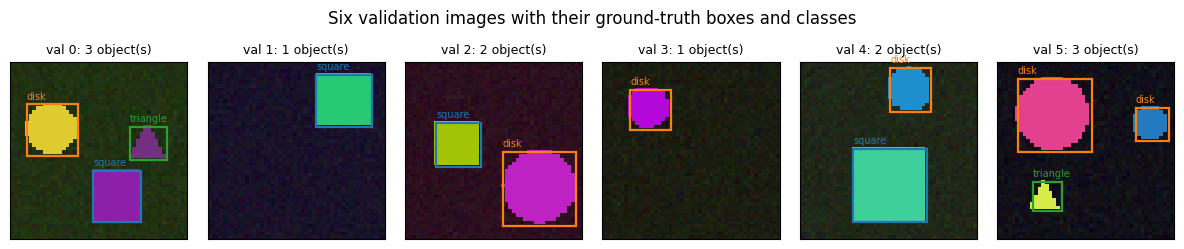

In [4]:
CLASS_COLORS = ['#ff7f0e', '#1f77b4', '#2ca02c']

def draw_boxes(ax, boxes, labels, scores=None, color=None, ls='-', lw=1.6):
    '''boxes: (n,4) normalized cxcywh; draws them in pixel units on ax.'''
    for i, (b, l) in enumerate(zip(boxes, labels)):
        cx, cy, w, h = [float(v) * IMG for v in b]
        c = color or CLASS_COLORS[int(l)]
        ax.add_patch(mpatches.Rectangle((cx - w / 2, cy - h / 2), w, h, fill=False, edgecolor=c, lw=lw, ls=ls))
        txt = CLASS_NAMES[int(l)] if scores is None else f'{CLASS_NAMES[int(l)]} {float(scores[i]):.2f}'
        ax.text(cx - w / 2, cy - h / 2 - 1, txt, color=c, fontsize=7, va='bottom')

fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
for k, ax in enumerate(axes):
    ax.imshow(Xva[k].permute(1, 2, 0).numpy())
    draw_boxes(ax, Bva[k], Lva[k])
    ax.set_title(f'val {k}: {len(Bva[k])} object(s)', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Six validation images with their ground-truth boxes and classes', y=1.02)
plt.tight_layout(); plt.show()

## 1. Boxes, IoU and generalized IoU

The slide on DETR's loss terms says why plain $L_1$ is not enough for boxes:

> "Commonly used L1 loss has different scales for small and large boxes even if their relative errors are similar. To mitigate this issue, bounding box loss is defined as linear combination of L1 loss and generalized IoU loss, which is scale-invariant."

**Intersection over union** compares two boxes $A$ and $B$ by $\mathrm{IoU} = \frac{|A \cap B|}{|A \cup B|}$. It is scale-invariant, but it has a flaw as a loss: when the boxes do not overlap it is exactly $0$ no matter how far apart they are, so it carries no gradient. **Generalized IoU** (*Rezatofighi et al., CVPR 2019*) fixes this with the smallest enclosing box $C$:

$$\mathrm{GIoU}(A, B) = \mathrm{IoU}(A, B) - \frac{|C \setminus (A \cup B)|}{|C|} \in (-1, 1].$$

The second term is the fraction of the enclosing box that is empty. For overlapping boxes it is small; for distant boxes it approaches $1$, so GIoU keeps decreasing toward $-1$ as the boxes separate. The GIoU loss is $\mathcal{L}_{\mathrm{iou}} = 1 - \mathrm{GIoU}$.

We build both from scratch on batches of corner-format boxes, and check them against `torchvision.ops.box_iou` and `torchvision.ops.generalized_box_iou`.

In [5]:
def box_cxcywh_to_xyxy(b):
    '''(..., 4) normalized (cx, cy, w, h) -> (x0, y0, x1, y1).'''
    cx, cy, w, h = b.unbind(-1)
    return torch.stack([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2], dim=-1)

def box_xyxy_to_cxcywh(b):
    x0, y0, x1, y1 = b.unbind(-1)
    return torch.stack([(x0 + x1) / 2, (y0 + y1) / 2, x1 - x0, y1 - y0], dim=-1)

def iou_scratch(a, b):
    '''Pairwise IoU. a: (N,4), b: (M,4), both xyxy. Returns (N,M) IoU and (N,M) union area.'''
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    lt = torch.max(a[:, None, :2], b[None, :, :2])          # top-left of the intersection
    rb = torch.min(a[:, None, 2:], b[None, :, 2:])          # bottom-right of the intersection
    wh = (rb - lt).clamp(min=0)
    inter = wh[..., 0] * wh[..., 1]
    union = area_a[:, None] + area_b[None, :] - inter
    return inter / union, union

def giou_scratch(a, b):
    '''Pairwise generalized IoU, (N,M). GIoU = IoU - |C minus (A u B)| / |C| with C the enclosing box.'''
    iou, union = iou_scratch(a, b)
    lt = torch.min(a[:, None, :2], b[None, :, :2])          # enclosing box C
    rb = torch.max(a[:, None, 2:], b[None, :, 2:])
    wh = (rb - lt).clamp(min=0)
    C = wh[..., 0] * wh[..., 1]
    return iou - (C - union) / C

set_seed(0)
a = box_cxcywh_to_xyxy(torch.rand(6, 4) * 0.5 + 0.25)
b = box_cxcywh_to_xyxy(torch.rand(4, 4) * 0.5 + 0.25)
iou_ref, giou_ref = box_iou(a, b), generalized_box_iou(a, b)
iou_mine, _ = iou_scratch(a, b)
giou_mine = giou_scratch(a, b)
assert torch.allclose(iou_mine, iou_ref, atol=1e-6)
assert torch.allclose(giou_mine, giou_ref, atol=1e-6)
print(f'IoU  from scratch vs torchvision.ops.box_iou:              max |diff| = {(iou_mine - iou_ref).abs().max():.2e}')
print(f'GIoU from scratch vs torchvision.ops.generalized_box_iou:  max |diff| = {(giou_mine - giou_ref).abs().max():.2e}')
print(f'GIoU range on these random pairs: [{giou_mine.min():.3f}, {giou_mine.max():.3f}]  (IoU is 0 for {int((iou_mine == 0).sum())} of {iou_mine.numel()} pairs, GIoU never is)')
assert torch.allclose(box_cxcywh_to_xyxy(box_xyxy_to_cxcywh(a)), a, atol=1e-6)
print('round trip xyxy -> cxcywh -> xyxy returns the same boxes: assert PASSED')

IoU  from scratch vs torchvision.ops.box_iou:              max |diff| = 0.00e+00
GIoU from scratch vs torchvision.ops.generalized_box_iou:  max |diff| = 0.00e+00
GIoU range on these random pairs: [-0.375, 0.506]  (IoU is 0 for 0 of 24 pairs, GIoU never is)
round trip xyxy -> cxcywh -> xyxy returns the same boxes: assert PASSED


### 1a. The slide's claim, measured: $L_1$ depends on scale, GIoU does not

Take a small box and a large box, and shift each by **the same relative error** (20% of its own width). If the slide is right, the $L_1$ loss should differ by the ratio of the box sizes while the GIoU loss is identical.

In [6]:
def shift_pair(w, frac):
    '''A box of width w and the same box shifted by frac * w. Returns both in cxcywh.'''
    gt = torch.tensor([[0.5, 0.5, w, w]])
    pred = gt.clone(); pred[0, 0] += frac * w
    return gt, pred

print(f'{"box width":>10} {"shift":>8} {"L1 loss":>9} {"IoU":>7} {"GIoU loss":>10}')
for w in [0.1, 0.2, 0.4]:
    gt, pred = shift_pair(w, 0.20)
    l1 = (gt - pred).abs().sum().item()
    iou = iou_scratch(box_cxcywh_to_xyxy(gt), box_cxcywh_to_xyxy(pred))[0].item()
    giou_loss = 1 - giou_scratch(box_cxcywh_to_xyxy(gt), box_cxcywh_to_xyxy(pred)).item()
    print(f'{w:>10.2f} {0.2*w:>8.3f} {l1:>9.3f} {iou:>7.3f} {giou_loss:>10.3f}')
print('\nSame 20% relative error: the L1 loss grows in proportion to the box, the GIoU loss is the same number.')

 box width    shift   L1 loss     IoU  GIoU loss
      0.10    0.020     0.020   0.667      0.333
      0.20    0.040     0.040   0.667      0.333
      0.40    0.080     0.080   0.667      0.333

Same 20% relative error: the L1 loss grows in proportion to the box, the GIoU loss is the same number.


### 1b. IoU versus GIoU as a box slides away

The static sweep below moves box $B$ across box $A$ and off to the right. IoU rises, peaks at $1$ when the boxes coincide, drops to $0$ at the moment they stop overlapping and stays there. GIoU tracks IoU while they overlap and then keeps falling toward $-1$: the enclosing box grows and empties. That tail is what gives a non-overlapping prediction a gradient to follow.

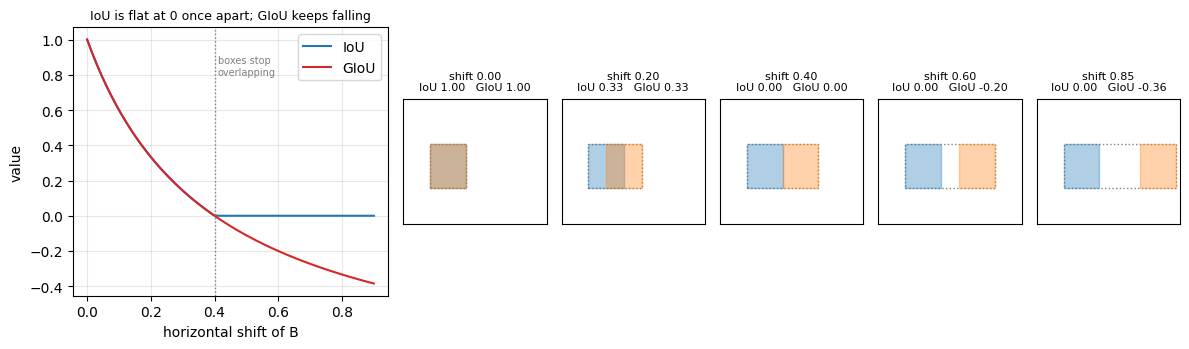

In [7]:
def giou_pair(A, B):
    '''IoU, GIoU and the enclosing box for two single boxes in xyxy.'''
    iou = iou_scratch(A[None], B[None])[0][0, 0].item()
    giou = giou_scratch(A[None], B[None])[0, 0].item()
    C = torch.cat([torch.min(A[:2], B[:2]), torch.max(A[2:], B[2:])])
    return iou, giou, C

def draw_pair(ax, A, B, title):
    iou, giou, C = giou_pair(A, B)
    ax.add_patch(mpatches.Rectangle(C[:2], *(C[2:] - C[:2]), fill=False, ls=':', edgecolor='gray', lw=1))
    ax.add_patch(mpatches.Rectangle(A[:2], *(A[2:] - A[:2]), facecolor='#1f77b4', alpha=0.35, edgecolor='#1f77b4'))
    ax.add_patch(mpatches.Rectangle(B[:2], *(B[2:] - B[:2]), facecolor='#ff7f0e', alpha=0.35, edgecolor='#ff7f0e'))
    ax.set_xlim(-0.2, 1.4); ax.set_ylim(-0.2, 1.2); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{title}\nIoU {iou:.2f}   GIoU {giou:.2f}', fontsize=8)

A_box = torch.tensor([0.1, 0.2, 0.5, 0.7])                         # fixed box A, xyxy
shifts = np.linspace(0.0, 0.9, 60)
ious, gious = [], []
for s in shifts:
    B_box = A_box + torch.tensor([s, 0.0, s, 0.0])
    i, g, _ = giou_pair(A_box, B_box); ious.append(i); gious.append(g)

fig = plt.figure(figsize=(12, 3.6))
gs = fig.add_gridspec(1, 6, width_ratios=[2.2, 1, 1, 1, 1, 1])
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(shifts, ious, label='IoU', color='#1f77b4'); ax0.plot(shifts, gious, label='GIoU', color='#d62728')
ax0.axvline(0.4, color='gray', ls=':', lw=1); ax0.text(0.41, 0.8, 'boxes stop\noverlapping', fontsize=7, color='gray')
ax0.set_xlabel('horizontal shift of B'); ax0.set_ylabel('value'); ax0.legend(); ax0.grid(alpha=0.3)
ax0.set_title('IoU is flat at 0 once apart; GIoU keeps falling', fontsize=9)
for k, s in enumerate([0.0, 0.2, 0.4, 0.6, 0.85]):
    ax = fig.add_subplot(gs[0, k + 1])
    draw_pair(ax, A_box, A_box + torch.tensor([s, 0.0, s, 0.0]), f'shift {s:.2f}')
plt.tight_layout(); plt.show()

### Widget 1: the GIoU explorer

Drag box $B$ around box $A$ with `dx`, `dy` and change its size with `scale`. The dotted rectangle is the enclosing box $C$. Watch two things: once the boxes separate, `IoU` freezes at $0$ while `GIoU` keeps reporting how far apart they are; and a box that is far larger or smaller than $A$ is penalised by GIoU even when it fully contains, or is contained in, $A$.

In [8]:
def giou_explorer(dx=0.3, dy=0.0, scale=1.0):
    A = torch.tensor([0.2, 0.3, 0.6, 0.7])
    cx, cy = (A[0] + A[2]) / 2 + dx, (A[1] + A[3]) / 2 + dy
    w, h = (A[2] - A[0]) * scale, (A[3] - A[1]) * scale
    B = torch.tensor([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2])
    iou, giou, C = giou_pair(A, B)
    fig, ax = plt.subplots(figsize=(4.6, 4.2))
    draw_pair(ax, A, B, f'A (blue) and B (orange), enclosing box C dotted')
    ax.set_xlim(-0.6, 1.6); ax.set_ylim(-0.6, 1.6)
    ax.set_title(f'IoU = {iou:.3f}    GIoU = {giou:.3f}    GIoU loss = {1 - giou:.3f}', fontsize=9)
    plt.tight_layout(); plt.show()

interact(giou_explorer,
         dx=FloatSlider(min=-0.8, max=0.8, step=0.05, value=0.3, description='dx'),
         dy=FloatSlider(min=-0.8, max=0.8, step=0.05, value=0.0, description='dy'),
         scale=FloatSlider(min=0.3, max=2.5, step=0.1, value=1.0, description='scale'));

interactive(children=(FloatSlider(value=0.3, description='dx', max=0.8, min=-0.8, step=0.05), FloatSlider(valu…

## 2. The DETR architecture

*Carion et al., End-to-End Object Detection with Transformers, ECCV 2020.* The slides summarise DETR in one sentence and two components:

> "DETR views object detection as a direct set prediction problem. The main components of DETR are: a set-based global loss that forces unique predictions via bipartite matching; a transformer encoder-decoder architecture."

The architecture slides walk through the pipeline:

1. A **CNN backbone** turns the image into a feature map $(C, H, W)$.
2. The feature map is **flattened** into $HW$ tokens and a **positional encoding** is added, so the encoder knows where each token came from.
3. A **transformer encoder** (self-attention and FFNs) lets every token see the whole image.
4. A **transformer decoder** receives $N$ learned **object queries**. Each decoder layer does self-attention among the queries (so they can coordinate and avoid duplicates) and cross-attention from the queries to the encoder output.
5. Every output embedding goes through a **class head** with $K + 1$ outputs (the extra one is $\varnothing$, "no object") and a **box head** that predicts $(c_x, c_y, w, h)$ through a sigmoid.

All $N$ predictions are made **in parallel**, in one pass. The model is not told how many objects there are; it predicts $N$ slots and marks the unused ones $\varnothing$.

### 2a. The backbone and the 2D sinusoidal positional encoding

DETR uses a sinusoidal encoding like the original transformer, but in **two dimensions**: half of the channels encode the row and half encode the column, each with the usual alternating sine and cosine at geometrically spaced frequencies, with positions normalized to $[0, 2\pi]$. We implement the vectorised version and check it against a plain loop that follows the formula one entry at a time.

vectorised sine_pos_2d matches the entry-by-entry loop: (144, 64) max |diff| = 2.4e-07


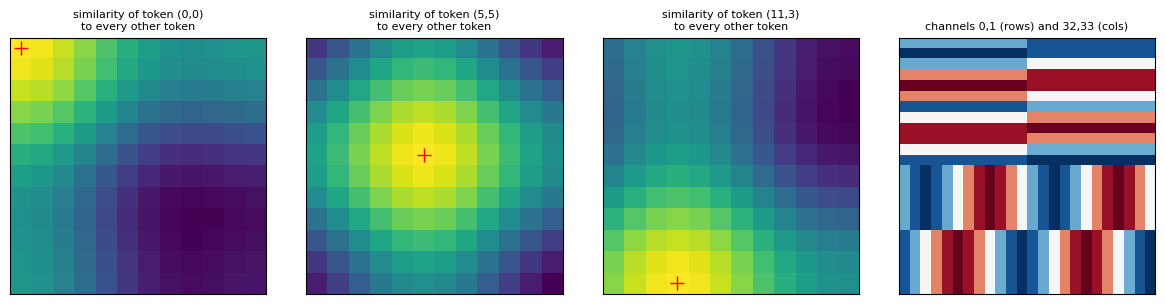

In [9]:
def sine_pos_2d(h, w, d, temperature=10000.0):
    '''DETR's 2D sinusoidal positional encoding. Returns (h*w, d): first d/2 channels encode y, last d/2 encode x.'''
    npf = d // 2                                                        # channels per axis
    y = (torch.arange(h, dtype=torch.float32)[:, None].expand(h, w) + 1) / h * 2 * math.pi
    x = (torch.arange(w, dtype=torch.float32)[None, :].expand(h, w) + 1) / w * 2 * math.pi
    dim_t = temperature ** (2 * (torch.arange(npf) // 2) / npf)         # frequencies, paired for sin/cos
    px, py = x[..., None] / dim_t, y[..., None] / dim_t
    px = torch.stack([px[..., 0::2].sin(), px[..., 1::2].cos()], dim=-1).flatten(-2)
    py = torch.stack([py[..., 0::2].sin(), py[..., 1::2].cos()], dim=-1).flatten(-2)
    return torch.cat([py, px], dim=-1).reshape(h * w, d)

def sine_pos_2d_loop(h, w, d, temperature=10000.0):
    '''Reference: the same encoding written entry by entry from the formula.'''
    npf = d // 2
    out = torch.zeros(h, w, d)
    for i in range(h):
        for j in range(w):
            for axis, pos in enumerate([(i + 1) / h * 2 * math.pi, (j + 1) / w * 2 * math.pi]):
                for c in range(npf):
                    freq = temperature ** (2 * (c // 2) / npf)
                    out[i, j, axis * npf + c] = math.sin(pos / freq) if c % 2 == 0 else math.cos(pos / freq)
    return out.reshape(h * w, d)

pe = sine_pos_2d(12, 12, 64)
assert torch.allclose(pe, sine_pos_2d_loop(12, 12, 64), atol=1e-5)
print('vectorised sine_pos_2d matches the entry-by-entry loop:', tuple(pe.shape),
      f'max |diff| = {(pe - sine_pos_2d_loop(12, 12, 64)).abs().max():.1e}')

# What the encoding buys us: dot products between encodings decay with distance, in both axes.
sim = (pe @ pe.T).reshape(12, 12, 12, 12)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (r, c) in zip(axes[:3], [(0, 0), (5, 5), (11, 3)]):
    im = ax.imshow(sim[r, c].numpy(), cmap='viridis'); ax.plot(c, r, 'r+', ms=10)
    ax.set_title(f'similarity of token ({r},{c})\nto every other token', fontsize=8); ax.set_xticks([]); ax.set_yticks([])
axes[3].imshow(pe.reshape(12, 12, 64)[:, :, [0, 1, 32, 33]].permute(2, 0, 1).reshape(24, 24).numpy(), cmap='RdBu')
axes[3].set_title('channels 0,1 (rows) and 32,33 (cols)', fontsize=8); axes[3].set_xticks([]); axes[3].set_yticks([])
plt.tight_layout(); plt.show()

### 2b. Encoder and decoder layers, written out and verified

We write the two layer types ourselves from `nn.MultiheadAttention`, `nn.LayerNorm` and a two-layer FFN, because we will want the **cross-attention weights** later and because DETR adds the positional encoding to the queries and keys of *every* layer, not just the input. Two conventions to notice in the code:

- In the encoder, $q = k = x + \mathrm{pos}$ but the values are the plain $x$.
- In the decoder, the object queries play the role of positional encoding for the query side, the encoder output carries the image positional encoding on the key side, and the decoder starts from an all-zero target $t = 0$ (the query embeddings are added at every layer, so the first self-attention already sees them).

Our encoder layer is a post-norm transformer layer, so with the positional encoding set to zero it must equal PyTorch's `nn.TransformerEncoderLayer`. We copy the weights across and assert that it does.

In [10]:
class EncLayer(nn.Module):
    '''Post-norm transformer encoder layer. pos is added to q and k only (DETR convention).'''
    def __init__(self, d, heads, ffn):
        super().__init__()
        self.attn = nn.MultiheadAttention(d, heads, batch_first=True)
        self.ff = nn.Sequential(nn.Linear(d, ffn), nn.ReLU(), nn.Linear(ffn, d))
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
    def forward(self, x, pos):
        q = k = x + pos
        a, w = self.attn(q, k, x, need_weights=True)                    # w: (B, HW, HW) averaged over heads
        x = self.n1(x + a)
        x = self.n2(x + self.ff(x))
        self.last_attn = w.detach()
        return x

class DecLayer(nn.Module):
    '''Decoder layer: self-attention among queries, cross-attention to the encoder memory, FFN.'''
    def __init__(self, d, heads, ffn):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d, heads, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d, heads, batch_first=True)
        self.ff = nn.Sequential(nn.Linear(d, ffn), nn.ReLU(), nn.Linear(ffn, d))
        self.n1, self.n2, self.n3 = nn.LayerNorm(d), nn.LayerNorm(d), nn.LayerNorm(d)
    def forward(self, t, qpos, mem, pos, self_mask=None):
        q = k = t + qpos
        a, _ = self.self_attn(q, k, t, attn_mask=self_mask, need_weights=False)
        t = self.n1(t + a)
        a, w = self.cross_attn(t + qpos, mem + pos, mem, need_weights=True)   # w: (B, N, HW)
        t = self.n2(t + a)
        t = self.n3(t + self.ff(t))
        self.last_cross = w.detach()
        return t

# Verify EncLayer against nn.TransformerEncoderLayer with the same weights (pos = 0).
set_seed(0)
d, heads, ffn = 64, 4, 128
ref = nn.TransformerEncoderLayer(d, heads, ffn, dropout=0.0, batch_first=True).eval()
mine = EncLayer(d, heads, ffn).eval()
mapping = {'attn.in_proj_weight': ref.self_attn.in_proj_weight, 'attn.in_proj_bias': ref.self_attn.in_proj_bias,
           'attn.out_proj.weight': ref.self_attn.out_proj.weight, 'attn.out_proj.bias': ref.self_attn.out_proj.bias,
           'ff.0.weight': ref.linear1.weight, 'ff.0.bias': ref.linear1.bias,
           'ff.2.weight': ref.linear2.weight, 'ff.2.bias': ref.linear2.bias,
           'n1.weight': ref.norm1.weight, 'n1.bias': ref.norm1.bias, 'n2.weight': ref.norm2.weight, 'n2.bias': ref.norm2.bias}
mine.load_state_dict({k: v.detach().clone() for k, v in mapping.items()})
x = torch.randn(2, 10, d)
with torch.no_grad():
    out_ref, out_mine = ref(x), mine(x, torch.zeros_like(x))
assert torch.allclose(out_ref, out_mine, atol=1e-5)
print(f'EncLayer vs nn.TransformerEncoderLayer (same weights): max |diff| = {(out_ref - out_mine).abs().max():.1e}')
print('stored attention map shape:', tuple(mine.last_attn.shape), '(batch, tokens, tokens), rows sum to',
      f'{mine.last_attn[0].sum(-1).mean():.4f}')

EncLayer vs nn.TransformerEncoderLayer (same weights): max |diff| = 0.0e+00
stored attention map shape: (2, 10, 10) (batch, tokens, tokens), rows sum to 1.0000


### 2c. The tiny DETR: backbone, encoder, object queries, decoder, heads

The slides say the decoder "produces output embeddings for each object query" and that "these embeddings include class probabilities, bounding box coordinates, and a special no-object class". Our `TinyDETR` follows the original at a fraction of the size:

| piece | original DETR | tiny DETR here |
|---|---|---|
| backbone | ResNet-50, stride 32 | 3 convs, stride 4 (a $48 \times 48$ image gives a $12 \times 12$ map, 144 tokens) |
| $d$, heads, FFN | 256, 8, 2048 | 64, 4, 128 |
| encoder / decoder layers | 6 / 6 | 2 / 2 |
| object queries $N$ | 100 | 6 (our images have at most 3 objects) |
| heads | linear class head, 3-layer MLP box head | the same |

As in DETR, the decoder returns the output of **every** layer so we can put a loss on each ("auxiliary decoding losses"), and the box head ends in a sigmoid so boxes land in $[0,1]^4$. Two extra modules, `label_enc` and `box_enc`, are unused until section 9, where they turn noisy ground-truth boxes into denoising queries.

In [11]:
class TinyDETR(nn.Module):
    def __init__(self, num_classes=K, d=64, heads=4, n_enc=2, n_dec=2, ffn=128, n_queries=6):
        super().__init__()
        self.d, self.n_queries, self.num_classes = d, n_queries, num_classes
        self.backbone = nn.Sequential(                                  # stride 4
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, d, 3, padding=1))
        self.enc = nn.ModuleList([EncLayer(d, heads, ffn) for _ in range(n_enc)])
        self.dec = nn.ModuleList([DecLayer(d, heads, ffn) for _ in range(n_dec)])
        self.query_embed = nn.Embedding(n_queries, d)                   # the N learned object queries
        self.dec_norm = nn.LayerNorm(d)
        self.class_head = nn.Linear(d, num_classes + 1)                 # K real classes + "no object"
        self.box_head = nn.Sequential(nn.Linear(d, d), nn.ReLU(), nn.Linear(d, d), nn.ReLU(), nn.Linear(d, 4))
        # used only for denoising queries (section 9): content from a label, position from a box
        self.label_enc = nn.Embedding(num_classes + 1, d)
        self.box_enc = nn.Sequential(nn.Linear(d, d), nn.ReLU(), nn.Linear(d, d))

    def box_pos(self, boxes):
        '''Sinusoidal embedding of (B, n, 4) boxes -> (B, n, d): each coordinate gets d/4 channels.'''
        npf = self.d // 4
        dim_t = 10000 ** (2 * (torch.arange(npf, device=boxes.device) // 2) / npf)
        p = boxes[..., None] * 2 * math.pi / dim_t                     # (B, n, 4, npf)
        p = torch.stack([p[..., 0::2].sin(), p[..., 1::2].cos()], dim=-1).flatten(-2)
        return self.box_enc(p.flatten(-2))

    def forward(self, x, dn=None, trace=False):
        B = x.shape[0]
        f = self.backbone(x)                                            # (B, d, h, w)
        h, w = f.shape[-2:]
        mem = f.flatten(2).transpose(1, 2)                              # (B, hw, d): the tokens
        pos = sine_pos_2d(h, w, self.d).to(x.device)[None].expand(B, -1, -1)
        if trace: print(f'backbone map {tuple(f.shape)} -> {mem.shape[1]} tokens of dim {self.d}; pos enc {tuple(pos.shape)}')
        for layer in self.enc:
            mem = layer(mem, pos)
        qpos = self.query_embed.weight[None].expand(B, -1, -1)          # (B, N, d)
        self_mask = None
        if dn is not None:                                              # append denoising queries (section 9)
            qpos = torch.cat([qpos, self.label_enc(dn['labels']) + self.box_pos(dn['boxes'])], dim=1)
            self_mask = dn['mask']
        t = torch.zeros_like(qpos)                                      # decoder input is zeros; queries enter as qpos
        outs = []
        for layer in self.dec:
            t = layer(t, qpos, mem, pos, self_mask)
            tn = self.dec_norm(t)
            outs.append((self.class_head(tn), self.box_head(tn).sigmoid()))   # one prediction set per layer
        if trace: print(f'decoder: {len(outs)} layers x {qpos.shape[1]} queries -> logits {tuple(outs[-1][0].shape)}, boxes {tuple(outs[-1][1].shape)}')
        return outs

set_seed(0)
model = TinyDETR().to(device)
with torch.no_grad():
    outs = model(Xva[:2].to(device), trace=True)
print(f'parameters: {count_params(model):,}  (backbone {count_params(model.backbone):,}, '
      f'encoder {count_params(model.enc):,}, decoder {count_params(model.dec):,}, queries {count_params(model.query_embed):,})')
print('boxes are in [0,1] thanks to the sigmoid:', f'{outs[-1][1].min():.3f} .. {outs[-1][1].max():.3f}')

backbone map (2, 64, 12, 12) -> 144 tokens of dim 64; pos enc (2, 144, 64)
decoder: 2 layers x 6 queries -> logits (2, 6, 4), boxes (2, 6, 4)
parameters: 241,672  (backbone 56,320, encoder 66,944, decoder 100,480, queries 384)
boxes are in [0,1] thanks to the sigmoid: 0.501 .. 0.517


## 3. Bipartite matching

The bipartite matching slides state the problem: DETR predicts $N$ objects in one pass, with $N$ larger than any plausible object count, and it does not rely on "heuristic assignment rules for matching proposals or anchors to ground truth" (the anchor IoU thresholds of Faster R-CNN). Instead the ground truth $y$ is **padded with $\varnothing$** up to size $N$, and one searches for the permutation $\sigma \in S_N$ with the lowest total cost:

$$\hat\sigma = \arg\min_{\sigma \in S_N} \sum_i^N \mathcal{L}_{\mathrm{match}}\big(y_i, \hat y_{\sigma(i)}\big), \qquad
\mathcal{L}_{\mathrm{match}}\big(y_i, \hat y_{\sigma(i)}\big) = -\mathbb{1}_{\{c_i \neq \varnothing\}}\, \hat p_{\sigma(i)}(c_i) + \mathbb{1}_{\{c_i \neq \varnothing\}}\, \mathcal{L}_{\mathrm{box}}\big(b_i, \hat b_{\sigma(i)}\big).$$

Each ground-truth element is $y_i = (c_i, b_i)$; $\hat p_{\sigma(i)}(c_i)$ is the probability the matched prediction gives to the true class and $\mathcal{L}_{\mathrm{box}}$ is the $L_1$ plus GIoU loss from section 1. Padded $\varnothing$ entries cost nothing whichever prediction they get, so only the $M$ real objects matter and the problem is: **assign each real object to a distinct prediction at minimum cost**. That is the classical assignment problem, solved exactly by the **Hungarian algorithm** (*Kuhn, Naval Research Logistics Quarterly 1955*) in $O(N^3)$.

Note the matching uses the probability $\hat p$ rather than $-\log \hat p$; the DETR paper does this so that the class term and the box term are on comparable scales. The weights DETR uses are $\lambda_{\mathrm{cls}} = 1$, $\lambda_{L1} = 5$, $\lambda_{\mathrm{iou}} = 2$.

### 3a. Brute force on a tiny case, then `scipy.optimize.linear_sum_assignment`

With $N = 5$ predictions and $M = 2$ objects there are only $5 \times 4 = 20$ injective assignments, so we can enumerate them all and confirm that the Hungarian solver returns the cheapest one.

In [12]:
def match_cost(prob, boxes, tgt_labels, tgt_boxes, w_cls=1.0, w_l1=5.0, w_giou=2.0):
    '''Cost matrix (N predictions x M objects) of the slide's L_match, for one image.
    prob: (N, K+1) class probabilities; boxes: (N, 4) cxcywh; tgt_labels: (M,); tgt_boxes: (M, 4).'''
    cost_cls = -prob[:, tgt_labels]                                       # -p_hat(c_i)
    cost_l1 = torch.cdist(boxes, tgt_boxes, p=1)                          # ||b_i - b_hat||_1
    cost_giou = -giou_scratch(box_cxcywh_to_xyxy(boxes), box_cxcywh_to_xyxy(tgt_boxes))
    return w_cls * cost_cls + w_l1 * cost_l1 + w_giou * cost_giou

def brute_force_match(cost):
    '''Enumerate every injective assignment of the M objects to the N predictions. Returns (best rows, best cost).'''
    N, M = cost.shape
    best, best_rows = float('inf'), None
    for rows in itertools.permutations(range(N), M):
        c = sum(cost[r, j].item() for j, r in enumerate(rows))
        if c < best:
            best, best_rows = c, rows
    return list(best_rows), best

set_seed(3)
N_pred, M_obj = 5, 2
prob = torch.rand(N_pred, K + 1).softmax(-1)
pred_boxes = torch.rand(N_pred, 4) * 0.4 + 0.3
tgt_labels = torch.tensor([0, 2]); tgt_boxes = torch.tensor([[0.3, 0.3, 0.2, 0.2], [0.7, 0.6, 0.3, 0.25]])
C = match_cost(prob, pred_boxes, tgt_labels, tgt_boxes)
print('cost matrix (rows = predictions, columns = objects):'); print(C)

bf_rows, bf_cost = brute_force_match(C)
rows, cols = linear_sum_assignment(C.numpy())
hung_cost = C[rows, cols].sum().item()
print(f'\nbrute force over {N_pred * (N_pred - 1)} assignments: objects -> predictions {bf_rows}, cost {bf_cost:.4f}')
print(f'Hungarian (scipy):                    objects -> predictions {rows[np.argsort(cols)].tolist()}, cost {hung_cost:.4f}')
assert abs(bf_cost - hung_cost) < 1e-5 and bf_rows == rows[np.argsort(cols)].tolist()
print('assert: Hungarian assignment == brute-force optimum   PASSED')

# how fast the two approaches scale: N! assignments to enumerate vs the cubic Hungarian algorithm
print(f'\n{"N":>4} {"N! (brute force)":>18} {"N^3 (Hungarian)":>16}')
for n in [5, 6, 10, 20, 100]:
    print(f'{n:>4} {math.factorial(n):>18.2e} {n ** 3:>16,}')

cost matrix (rows = predictions, columns = objects):
tensor([[4.3117, 3.9292],
        [2.9356, 5.0631],
        [3.0607, 5.8696],
        [1.1938, 4.7738],
        [2.9837, 4.8934]])

brute force over 20 assignments: objects -> predictions [3, 0], cost 5.1230
Hungarian (scipy):                    objects -> predictions [3, 0], cost 5.1230
assert: Hungarian assignment == brute-force optimum   PASSED

   N   N! (brute force)  N^3 (Hungarian)
   5           1.20e+02              125
   6           7.20e+02              216
  10           3.63e+06            1,000
  20           2.43e+18            8,000
 100          9.33e+157        1,000,000


### 3b. How the cost weights decide the assignment

The three terms of $\mathcal{L}_{\mathrm{match}}$ can disagree. Below, prediction 0 is **confident about the right class but badly placed**, prediction 1 has **the right box but the wrong class**, and predictions 2 and 3 are distractors. Which one the object is matched to depends on $\lambda_{\mathrm{cls}}, \lambda_{L1}, \lambda_{\mathrm{iou}}$. The static sweep raises the class weight from $1$ to $8$ and shows the assignment flip.

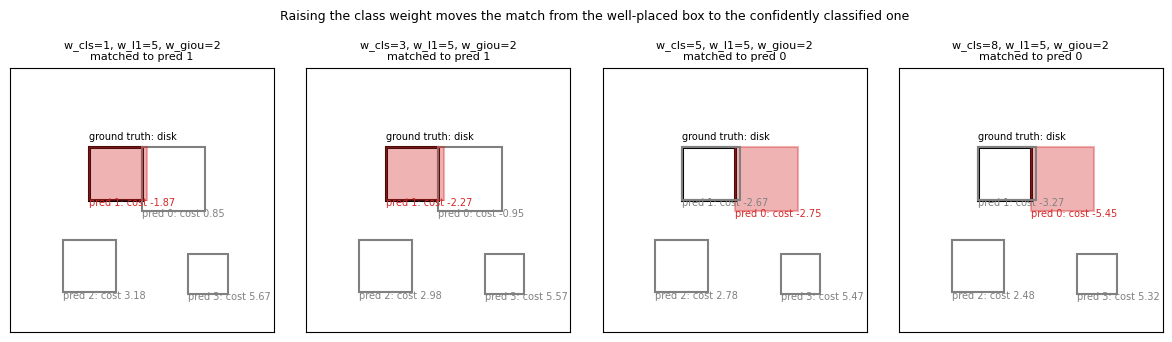

In [13]:
demo_prob = torch.tensor([[0.90, 0.05, 0.05, 0.00],      # pred 0: right class, poor box
                          [0.20, 0.10, 0.10, 0.60],      # pred 1: good box, unsure class (mostly "no object")
                          [0.10, 0.80, 0.05, 0.05],      # pred 2: wrong class
                          [0.05, 0.05, 0.10, 0.80]])     # pred 3: "no object"
demo_boxes = torch.tensor([[0.62, 0.42, 0.24, 0.24],
                           [0.41, 0.40, 0.22, 0.20],
                           [0.30, 0.75, 0.20, 0.20],
                           [0.75, 0.78, 0.15, 0.15]])
demo_tgt_labels = torch.tensor([0]); demo_tgt_boxes = torch.tensor([[0.40, 0.40, 0.20, 0.20]])

def show_assignment(ax, w_cls, w_l1, w_giou, title=None):
    C = match_cost(demo_prob, demo_boxes, demo_tgt_labels, demo_tgt_boxes, w_cls, w_l1, w_giou)
    r, c = linear_sum_assignment(C.numpy())
    ax.add_patch(mpatches.Rectangle(box_cxcywh_to_xyxy(demo_tgt_boxes[0])[:2], 0.2, 0.2, fill=False, edgecolor='k', lw=2.2))
    ax.text(0.30, 0.27, 'ground truth: disk', fontsize=7)
    for i, b in enumerate(demo_boxes):
        xy = box_cxcywh_to_xyxy(b)
        chosen = i == r[0]
        ax.add_patch(mpatches.Rectangle(xy[:2], b[2], b[3], fill=chosen, alpha=0.35 if chosen else 1,
                                        edgecolor='#d62728' if chosen else 'gray', facecolor='#d62728', lw=1.5))
        ax.text(xy[0], xy[3] + 0.02, f'pred {i}: cost {C[i, 0]:.2f}', fontsize=7, color='#d62728' if chosen else 'gray')
    ax.set_xlim(0, 1); ax.set_ylim(1, 0); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title or f'w_cls={w_cls:g}, w_l1={w_l1:g}, w_giou={w_giou:g}\nmatched to pred {r[0]}', fontsize=8)
    return int(r[0])

fig, axes = plt.subplots(1, 4, figsize=(12, 3.4))
for ax, w in zip(axes, [1, 3, 5, 8]):
    show_assignment(ax, w, 5, 2)
plt.suptitle('Raising the class weight moves the match from the well-placed box to the confidently classified one', y=1.02, fontsize=9)
plt.tight_layout(); plt.show()

### Widget 2: matching-cost weights versus assignment

Drag the three weights. With DETR's defaults (`w_cls=1, w_l1=5, w_giou=2`) the object goes to prediction 1, the good box. Raise `w_cls` until prediction 0 wins; then raise `w_giou` to pull it back. The number next to each box is its cost against the ground truth.

In [14]:
def matching_explorer(w_cls=1.0, w_l1=5.0, w_giou=2.0):
    fig, ax = plt.subplots(figsize=(4.8, 4.4))
    show_assignment(ax, w_cls, w_l1, w_giou)
    plt.tight_layout(); plt.show()

interact(matching_explorer,
         w_cls=FloatSlider(min=0, max=10, step=0.5, value=1.0, description='w_cls'),
         w_l1=FloatSlider(min=0, max=10, step=0.5, value=5.0, description='w_l1'),
         w_giou=FloatSlider(min=0, max=10, step=0.5, value=2.0, description='w_giou'));

interactive(children=(FloatSlider(value=1.0, description='w_cls', max=10.0, step=0.5), FloatSlider(value=5.0, …

### 3c. Padding with $\varnothing$ and the number of queries $N$

The slide's $y$ is "the set of ground truth objects padded with $\varnothing$ (no object) to match the size of $\hat y$". With $N$ queries and $M$ objects, $N - M$ of the targets are $\varnothing$. In our data $M \le 3$ and the mean is about $2$, so with $N = 6$ roughly two thirds of the slots are "no object" on every image; with the original DETR's $N = 100$ on COCO (about 7 objects per image) it is over 90%. This imbalance is why the class loss down-weights $\varnothing$ (next section). The sweep below pads the same scene with $N = 3, 6, 12$ queries (random predictions, seed fixed) and draws the matched pairs.

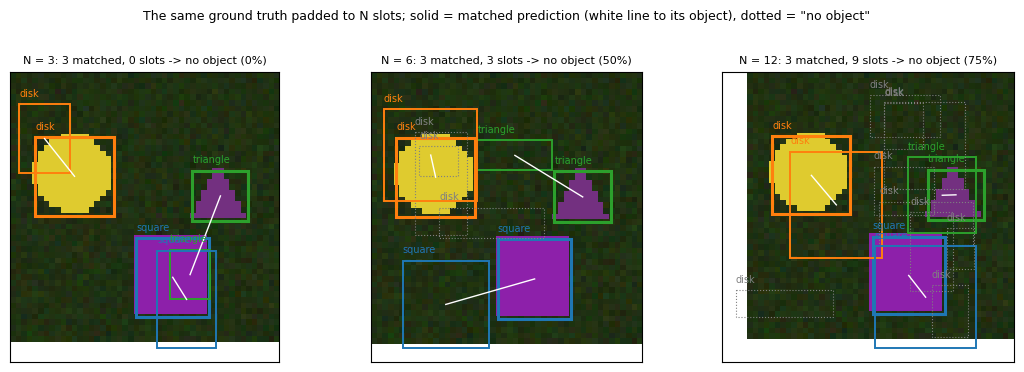

In [15]:
def padded_matching(N, image=0, seed=0):
    '''Random predictions for one val image, matched to its ground truth padded with "no object".'''
    g = torch.Generator().manual_seed(seed)
    prob = torch.rand(N, K + 1, generator=g).softmax(-1)
    boxes = torch.rand(N, 4, generator=g) * torch.tensor([0.8, 0.8, 0.3, 0.3]) + torch.tensor([0.1, 0.1, 0.1, 0.1])
    C = match_cost(prob, boxes, Lva[image], Bva[image])
    r, c = linear_sum_assignment(C.numpy())
    target = torch.full((N,), NO_OBJ); target[r] = Lva[image][c]
    return prob, boxes, r, c, target

def show_padded(ax, N, image=0):
    prob, boxes, r, c, target = padded_matching(N, image)
    ax.imshow(Xva[image].permute(1, 2, 0).numpy())
    draw_boxes(ax, Bva[image], Lva[image], lw=2.2)
    for i, b in enumerate(boxes):
        matched = i in r
        draw_boxes(ax, b[None], [int(target[i])] if matched else [0], color=None if matched else 'gray',
                   ls='-' if matched else ':', lw=1.4 if matched else 0.8)
    for ri, ci in zip(r, c):
        p, gt = boxes[ri], Bva[image][ci]
        ax.plot([p[0] * IMG, gt[0] * IMG], [p[1] * IMG, gt[1] * IMG], 'w-', lw=1)
    n_empty = int((target == NO_OBJ).sum())
    ax.set_title(f'N = {N}: {len(r)} matched, {n_empty} slots -> no object ({100 * n_empty / N:.0f}%)', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, N in zip(axes, [3, 6, 12]):
    show_padded(ax, N)
plt.suptitle('The same ground truth padded to N slots; solid = matched prediction (white line to its object), dotted = "no object"', y=1.02, fontsize=9)
plt.tight_layout(); plt.show()

### Widget 3: the number of queries

Slide `N` from 2 to 16. The ground truth does not change; the fraction of slots that must learn to say $\varnothing$ does. At `N = 2` on a three-object image one object cannot be matched at all, which is the failure mode of choosing $N$ too small; at `N = 16` almost every slot is a negative. Switch `image` to see scenes with 1, 2 or 3 objects.

In [16]:
def queries_explorer(N=6, image=0):
    fig, ax = plt.subplots(figsize=(4.6, 4.4))
    show_padded(ax, N, image)
    plt.tight_layout(); plt.show()

interact(queries_explorer,
         N=IntSlider(min=2, max=16, step=1, value=6, description='N queries'),
         image=IntSlider(min=0, max=5, step=1, value=0, description='image'));

interactive(children=(IntSlider(value=6, description='N queries', max=16, min=2), IntSlider(value=0, descripti…

## 4. The Hungarian loss

Once $\hat\sigma$ is fixed, the training loss is the slide's

$$\mathcal{L}_{\mathrm{Hungarian}}(y, \hat y) = \sum_{i=1}^{N} \Big[ -\log \hat p_{\hat\sigma(i)}(c_i) + \mathbb{1}_{\{c_i \neq \varnothing\}}\, \mathcal{L}_{\mathrm{box}}\big(b_i, \hat b_{\hat\sigma(i)}\big) \Big], \qquad
\mathcal{L}_{\mathrm{box}} = \lambda_{\mathrm{iou}}\, \mathcal{L}_{\mathrm{iou}} + \lambda_{L1}\, \|b_i - \hat b_{\hat\sigma(i)}\|_1 .$$

Three implementation details from the DETR paper that the formula hides:

- The class term is an ordinary cross-entropy over all $N$ slots, so the unmatched slots are trained to predict $\varnothing$. Because most slots are $\varnothing$, its weight in the cross-entropy is scaled down by `eos_coef = 0.1`.
- The box terms only exist for matched pairs and are averaged over the number of objects in the batch.
- The same loss is applied to the output of **every decoder layer** (auxiliary losses), each with its own matching.

The matching makes the loss a **set** loss: if we permute the $N$ predictions, the matching permutes with them and the loss does not change. We assert that.

In [17]:
@torch.no_grad()
def hungarian_match(logits, boxes, tgt_labels, tgt_boxes):
    '''Batched matching. Returns a list of (pred_idx, obj_idx) tensors, one per image.'''
    prob = logits.softmax(-1)
    out = []
    for b in range(logits.shape[0]):
        C = match_cost(prob[b], boxes[b], tgt_labels[b], tgt_boxes[b])
        r, c = linear_sum_assignment(C.detach().cpu().numpy())
        out.append((torch.as_tensor(r, dtype=torch.long, device=logits.device),
                    torch.as_tensor(c, dtype=torch.long, device=logits.device)))
    return out

def hungarian_loss(logits, boxes, tgt_labels, tgt_boxes, idx, eos_coef=0.1, w_l1=5.0, w_giou=2.0):
    '''The slide's Hungarian loss for a batch. logits (B,N,K+1), boxes (B,N,4), targets as lists per image.'''
    B, N, _ = logits.shape
    target_cls = torch.full((B, N), NO_OBJ, dtype=torch.long, device=logits.device)
    for b, (r, c) in enumerate(idx):
        target_cls[b, r] = tgt_labels[b][c]
    weight = torch.ones(K + 1, device=logits.device); weight[NO_OBJ] = eos_coef
    loss_ce = F.cross_entropy(logits.transpose(1, 2), target_cls, weight=weight)     # -log p over all N slots
    src = torch.cat([boxes[b, r] for b, (r, c) in enumerate(idx)])                   # matched predictions
    tgt = torch.cat([tgt_boxes[b][c] for b, (r, c) in enumerate(idx)])               # their objects
    n_obj = max(len(src), 1)
    loss_l1 = F.l1_loss(src, tgt, reduction='sum') / n_obj
    loss_giou = (1 - torch.diag(giou_scratch(box_cxcywh_to_xyxy(src), box_cxcywh_to_xyxy(tgt)))).sum() / n_obj
    return loss_ce + w_l1 * loss_l1 + w_giou * loss_giou, {'ce': loss_ce.item(), 'l1': loss_l1.item(), 'giou': loss_giou.item()}

set_seed(0)
xb = Xva[:8].to(device)
tl = [l.to(device) for l in Lva[:8]]; tb = [b.to(device) for b in Bva[:8]]
with torch.no_grad():
    logits, boxes = model(xb)[-1]
idx = hungarian_match(logits, boxes, tl, tb)
loss, parts = hungarian_loss(logits, boxes, tl, tb, idx)
print(f'untrained model, 8 images: loss {loss.item():.3f}  = ce {parts["ce"]:.3f} + 5 * l1 {parts["l1"]:.3f} + 2 * giou {parts["giou"]:.3f}')

# permutation invariance: shuffle the N predictions of every image and recompute
perm = torch.randperm(model.n_queries)
idx_p = hungarian_match(logits[:, perm], boxes[:, perm], tl, tb)
loss_p, _ = hungarian_loss(logits[:, perm], boxes[:, perm], tl, tb, idx_p)
assert torch.allclose(loss, loss_p, atol=1e-5)
print(f'after permuting the predictions with {perm.tolist()}: loss {loss_p.item():.3f}   (assert equal PASSED: a set loss)')

# and the matching really is the cheapest: enumerate every assignment of image 0 and compare with the Hungarian cost
C0 = match_cost(logits[0].softmax(-1), boxes[0], tl[0], tb[0])
costs = [sum(C0[r, j].item() for j, r in enumerate(rows)) for rows in itertools.permutations(range(model.n_queries), len(tl[0]))]
best, worst = min(costs), max(costs)
hung0 = C0[idx[0][0], idx[0][1]].sum().item()
assert abs(best - hung0) < 1e-5
print(f'image 0: Hungarian cost {hung0:.3f}, best of all assignments {best:.3f} (assert equal PASSED), worst {worst:.3f}, '
      f'{len(costs)} assignments checked')

untrained model, 8 images: loss 8.419  = ce 1.688 + 5 * l1 0.908 + 2 * giou 1.096
after permuting the predictions with [2, 5, 3, 0, 1, 4]: loss 8.419   (assert equal PASSED: a set loss)
image 0: Hungarian cost 12.324, best of all assignments 12.324 (assert equal PASSED), worst 12.394, 120 assignments checked


## 5. Training the tiny DETR

The slide on the decoder says the model "predicts these outputs in parallel for all object queries, allowing end-to-end training without additional post-processing steps". Here is that training, sized for a CPU:

- 2000 synthetic images, batch 32, AdamW with a one-cycle schedule peaking at $10^{-3}$, gradient clipping at $0.1$ as in DETR.
- Hungarian loss on both decoder layers (auxiliary loss).
- Every 100 steps we evaluate on the 200 validation images and keep the predictions on four fixed images for the widgets later.
- The optimizer, the schedule and the data order live in a small `DetrTrainer` object, so the run is split over **two cells of half the steps each** and no single cell runs for more than about half a minute on a CPU.

Two metrics, both computed from scratch:

- **Matched mean IoU**: match predictions to ground truth with the Hungarian solver and average the IoU of the matched pairs. It measures localization only.
- **AP50**: the usual detection metric at IoU $0.5$. Every prediction with its confidence (the largest non-$\varnothing$ probability) is ranked over the whole validation set; a prediction is a true positive if it has the right class, IoU $\ge 0.5$ with a ground-truth object nobody has claimed yet; AP is the area under the interpolated precision-recall curve. We check the implementation on a hand-computed example first.

In [18]:
def average_precision(dets, n_gt):
    '''dets: list of (score, is_true_positive). All-point interpolated AP.'''
    dets = sorted(dets, key=lambda t: -t[0])
    tp = np.cumsum([d[1] for d in dets]); fp = np.cumsum([1 - d[1] for d in dets])
    rec, prec = tp / max(n_gt, 1), tp / np.maximum(tp + fp, 1)
    mrec = np.concatenate([[0.0], rec, [rec[-1] if len(rec) else 0.0]])
    mpre = np.concatenate([[0.0], prec, [0.0]])
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    return float(np.sum((mrec[1:] - mrec[:-1]) * mpre[1:]))

# hand-computed check: 3 detections for 2 objects, ranked TP, FP, TP -> precision 1 at recall 0.5, 2/3 at recall 1
ap_hand = 0.5 * 1.0 + 0.5 * (2 / 3)
assert abs(average_precision([(0.9, 1), (0.8, 0), (0.7, 1)], 2) - ap_hand) < 1e-9
assert abs(average_precision([(0.9, 1), (0.8, 1)], 2) - 1.0) < 1e-9
print(f'AP on the hand example = {average_precision([(0.9, 1), (0.8, 0), (0.7, 1)], 2):.4f} (expected {ap_hand:.4f}); perfect ranking gives 1.0')

@torch.no_grad()
def evaluate(model, X, Bx, Lx, bs=100, size_range=None):
    '''Matched mean IoU and AP50 on a dataset.
    size_range=(lo, hi) scores only the objects whose box side in pixels lies in [lo, hi), following COCO's area-range
    evaluation: the matching and the IoU matrix still use every object; a prediction matched to an out-of-range object
    is ignored (neither TP nor FP); an unmatched prediction whose own side is out of range is ignored too.'''
    model.eval()
    ious, dets, n_gt = [], [], 0
    def in_range(side):
        return torch.ones_like(side, dtype=torch.bool) if size_range is None else (side >= size_range[0]) & (side < size_range[1])
    for i in range(0, len(X), bs):
        logits, boxes = model(X[i:i + bs].to(device))[-1]
        prob = logits.softmax(-1)
        tb = [b.to(device) for b in Bx[i:i + bs]]; tl = [l.to(device) for l in Lx[i:i + bs]]
        for b in range(logits.shape[0]):
            gt_in, pred_in = in_range(tb[b][:, 2] * IMG), in_range(boxes[b][:, 2] * IMG)
            if not gt_in.any():
                continue
            pb, gb = box_cxcywh_to_xyxy(boxes[b]), box_cxcywh_to_xyxy(tb[b])
            iou = box_iou(pb, gb)
            r, c = hungarian_match(logits[b:b + 1], boxes[b:b + 1], tl[b:b + 1], tb[b:b + 1])[0]
            ious += iou[r, c][gt_in[c]].tolist()                          # matched IoU of the in-range objects only
            scores, cls = prob[b][:, :K].max(-1)
            used = torch.zeros(len(gb), dtype=torch.bool, device=device)
            for q in scores.argsort(descending=True).tolist():
                ok = (iou[q] >= 0.5) & (cls[q] == tl[b]) & ~used
                if ok.any():
                    j = torch.where(ok)[0][iou[q][ok].argmax()]; used[j] = True
                    if gt_in[j]:
                        dets.append((scores[q].item(), 1))                # claimed an in-range object: true positive
                    # claimed an out-of-range object: ignored, as in COCO
                elif pred_in[q]:
                    dets.append((scores[q].item(), 0))                    # matches nothing and is in range: false positive
            n_gt += int(gt_in.sum())
    model.train()
    return float(np.mean(ious)), average_precision(dets, n_gt)

@torch.no_grad()
def predict(model, X, thresh=0.5):
    '''Final-layer predictions for a few images: list of (boxes, labels, scores) keeping non-empty slots above thresh.'''
    model.eval()
    logits, boxes = model(X.to(device))[-1]
    prob = logits.softmax(-1); model.train()
    out = []
    for b in range(len(X)):
        s, c = prob[b][:, :K].max(-1)
        keep = s > thresh
        out.append((boxes[b][keep].detach().cpu(), c[keep].detach().cpu(), s[keep].detach().cpu()))
    return out

miou0, ap0 = evaluate(model, Xva, Bva, Lva)
print(f'untrained model: matched mean IoU {miou0:.3f}, AP50 {ap0:.3f}')

AP on the hand example = 0.8333 (expected 0.8333); perfect ranking gives 1.0
untrained model: matched mean IoU 0.136, AP50 0.000


In [19]:
SNAP_IMAGES = [0, 1, 2, 3]                     # val images whose predictions we keep at every evaluation
EVAL_EVERY = 100

class DetrTrainer:
    '''Trains a TinyDETR with the Hungarian loss on every decoder layer. The optimizer, the one-cycle schedule and the
    data order live in this object, so one run can be spread over several cells with `run(until)`.
    curve: list of (step, val matched IoU, val AP50); snaps[step]: predictions on SNAP_IMAGES; seconds: total time.'''
    def __init__(self, model, steps, bs=32, lr=1e-3, use_dn=False, seed=0):
        set_seed(seed)
        self.model, self.steps, self.bs, self.use_dn = model.to(device).train(), steps, bs, use_dn
        self.opt = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)
        self.sched = torch.optim.lr_scheduler.OneCycleLR(self.opt, max_lr=lr, total_steps=steps, pct_start=0.1)
        self.gen = torch.Generator().manual_seed(seed)
        self.step, self.curve, self.snaps, self.seconds = 0, [], {}, 0.0

    def run(self, until, log_every=200):
        '''Train from the current step up to step `until`, evaluating every EVAL_EVERY steps and at the end. Returns the seconds this call took.'''
        until, t0 = min(until, self.steps), time.time()
        while True:
            s = self.step
            if (s % EVAL_EVERY == 0 or s == self.steps) and s not in self.snaps:
                miou, ap = evaluate(self.model, Xva, Bva, Lva)
                self.curve.append((s, miou, ap)); self.snaps[s] = predict(self.model, Xva[SNAP_IMAGES])
                if s % log_every == 0 or s == self.steps:
                    print(f'  step {s:4d}   val matched IoU {miou:.3f}   AP50 {ap:.3f}   ({self.seconds + time.time() - t0:5.1f} s)')
            if s >= until:
                break
            i = torch.randint(0, len(Xtr), (self.bs,), generator=self.gen)
            x = Xtr[i].to(device)
            tb = [Btr[j].to(device) for j in i.tolist()]; tl = [Ltr[j].to(device) for j in i.tolist()]
            dn = make_dn_queries(tl, tb, self.model.n_queries) if self.use_dn else None
            loss = 0.0
            for logits, boxes in self.model(x, dn):                      # one Hungarian loss per decoder layer
                lm, bm = logits[:, :self.model.n_queries], boxes[:, :self.model.n_queries]
                loss = loss + hungarian_loss(lm, bm, tl, tb, hungarian_match(lm, bm, tl, tb))[0]
                if dn is not None:
                    loss = loss + dn_loss(logits[:, self.model.n_queries:], boxes[:, self.model.n_queries:], dn)
            self.opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), 0.1)
            self.opt.step(); self.sched.step()
            self.step += 1
        dt = time.time() - t0; self.seconds += dt
        return dt

STEPS = 900
set_seed(0)
detr = TinyDETR()
trainer_detr = DetrTrainer(detr, STEPS)
print(f'training tiny DETR for {STEPS} steps, first half ...')
print(f'steps 0 to {STEPS // 2} done in {trainer_detr.run(STEPS // 2):.1f} s')

training tiny DETR for 900 steps, first half ...


  step    0   val matched IoU 0.136   AP50 0.000   (  0.1 s)


  step  200   val matched IoU 0.371   AP50 0.005   (  7.6 s)


  step  400   val matched IoU 0.565   AP50 0.102   ( 15.0 s)


steps 0 to 450 done in 16.8 s


In [20]:
print('second half ...')
print(f'steps {STEPS // 2} to {STEPS} done in {trainer_detr.run(STEPS):.1f} s')
curve_detr, snaps_detr, t_detr = trainer_detr.curve, trainer_detr.snaps, trainer_detr.seconds
miou_detr, ap_detr = curve_detr[-1][1], curve_detr[-1][2]
print(f'total {t_detr:.1f} s of training and evaluation: matched mean IoU {miou_detr:.3f}, AP50 {ap_detr:.3f}')

second half ...


  step  600   val matched IoU 0.700   AP50 0.353   ( 22.4 s)


  step  800   val matched IoU 0.745   AP50 0.454   ( 29.8 s)


  step  900   val matched IoU 0.749   AP50 0.459   ( 33.5 s)
steps 450 to 900 done in 16.7 s
total 33.5 s of training and evaluation: matched mean IoU 0.749, AP50 0.459


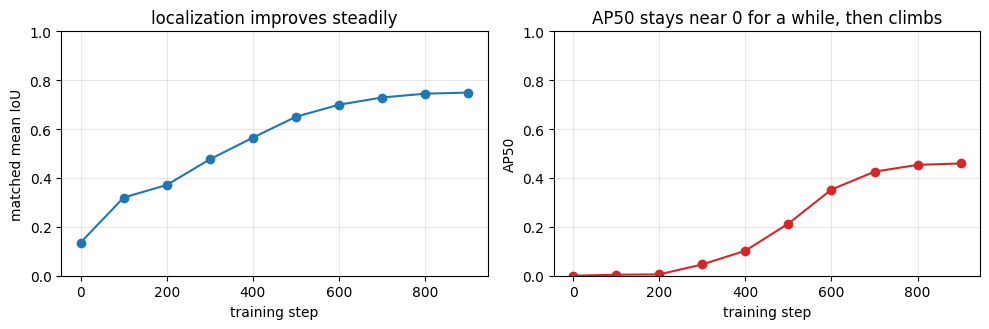

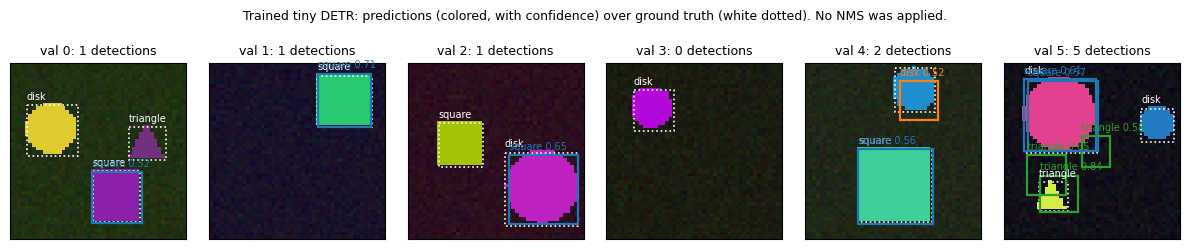

confident predictions per image: 2.12 for 1.92 objects per image
objects found (right class, IoU >= 0.5): 56%   |   of the confident predictions, 17% are duplicates of an object already found and 32% match no object


In [21]:
steps_axis = [c[0] for c in curve_detr]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(steps_axis, [c[1] for c in curve_detr], 'o-', color='#1f77b4'); axes[0].set_ylabel('matched mean IoU')
axes[1].plot(steps_axis, [c[2] for c in curve_detr], 'o-', color='#d62728'); axes[1].set_ylabel('AP50')
for ax in axes:
    ax.set_xlabel('training step'); ax.grid(alpha=0.3); ax.set_ylim(0, 1)
axes[0].set_title('localization improves steadily'); axes[1].set_title('AP50 stays near 0 for a while, then climbs')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
preds = predict(detr, Xva[:6])
for k, ax in enumerate(axes):
    ax.imshow(Xva[k].permute(1, 2, 0).numpy())
    draw_boxes(ax, Bva[k], Lva[k], color='white', ls=':', lw=1.2)
    draw_boxes(ax, *preds[k])
    ax.set_title(f'val {k}: {len(preds[k][0])} detections', fontsize=9); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Trained tiny DETR: predictions (colored, with confidence) over ground truth (white dotted). No NMS was applied.', y=1.03, fontsize=9)
plt.tight_layout(); plt.show()

@torch.no_grad()
def detection_audit(model, X, Bx, Lx, thresh=0.5):
    '''Count confident predictions per image and sort them into correct, duplicate (same object already claimed) and false.'''
    model.eval(); logits, boxes = model(X.to(device))[-1]; model.train()
    prob = logits.softmax(-1)
    n_conf, n_correct, n_dup, n_false = 0, 0, 0, 0
    for b in range(len(X)):
        s, c = prob[b][:, :K].max(-1)
        keep = s > thresh; n_conf += int(keep.sum())
        iou = box_iou(box_cxcywh_to_xyxy(boxes[b][keep]), box_cxcywh_to_xyxy(Bx[b].to(device)))
        claimed = torch.zeros(len(Bx[b]), dtype=torch.bool, device=device)
        for q in s[keep].argsort(descending=True).tolist():
            hit = (iou[q] >= 0.5) & (c[keep][q] == Lx[b].to(device))
            if hit.any() and not claimed[hit.nonzero()[0, 0]]:
                claimed[hit.nonzero()[0, 0]] = True; n_correct += 1
            elif hit.any():
                n_dup += 1
            else:
                n_false += 1
    n_obj = sum(len(b) for b in Bx)
    return n_conf / len(X), n_obj / len(X), n_correct / n_obj, n_dup / max(n_conf, 1), n_false / max(n_conf, 1)

conf_per_img, obj_per_img, recall, dup_frac, false_frac = detection_audit(detr, Xva, Bva, Lva)
print(f'confident predictions per image: {conf_per_img:.2f} for {obj_per_img:.2f} objects per image')
print(f'objects found (right class, IoU >= 0.5): {100 * recall:.0f}%   |   of the confident predictions, {100 * dup_frac:.0f}% are duplicates of an object already found and {100 * false_frac:.0f}% match no object')

The audit is worth reading carefully, because it shows the tiny DETR at the stage the DETR paper describes for the first part of its long schedule. Most objects are found with the right class, but the model fires **more confident boxes than there are objects**, and a good share of the extra boxes are duplicates: two or three queries have converged on the same object, and the box head of each has learned to draw it. No post-processing removes them: the decoder self-attention among the queries is the only architectural means of coordination, and the Hungarian loss is the only training pressure against duplicates, since it matches one prediction per object and asks the others to say $\varnothing$, with the $\varnothing$ class down-weighted by `eos_coef = 0.1`. With a longer schedule the duplicates thin out (the training scrubber in section 10 shows them thinning already), and section 9 will show why DINO's contrastive denoising attacks exactly this failure mode.

## 6. What the object queries learned

Nothing in the loss tells query 3 to look at the bottom-left of the image, yet DETR's queries end up **specialising by region and by box size** (the DETR paper's figure of prediction slots on COCO). The matching is what causes it: whichever query happens to win an object in a region gets the gradient for that region, and the self-attention among queries lets the others move elsewhere. We can see the same thing on our six queries by scattering the centre of every confident prediction each query made on the validation set.

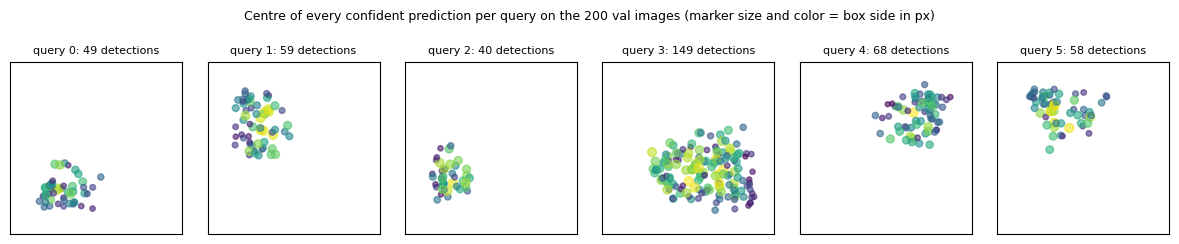

fraction of val images on which each query fires: ['0.25', '0.29', '0.20', '0.75', '0.34', '0.29']


In [22]:
@torch.no_grad()
def query_centers(model, X):
    model.eval()
    logits, boxes = model(X.to(device))[-1]
    model.train()
    prob = logits.softmax(-1)
    conf = prob[:, :, :K].max(-1).values                                 # (n_images, N)
    return boxes.detach().cpu(), conf.detach().cpu()

boxes_va, conf_va = query_centers(detr, Xva)
fig, axes = plt.subplots(1, detr.n_queries, figsize=(12, 2.3))
for q, ax in enumerate(axes):
    keep = conf_va[:, q] > 0.5
    b = boxes_va[keep, q]
    ax.scatter(b[:, 0] * IMG, b[:, 1] * IMG, s=8 + 200 * b[:, 2] * b[:, 3], c=b[:, 2] * IMG, cmap='viridis', alpha=0.6, vmin=8, vmax=20)
    ax.set_xlim(0, IMG); ax.set_ylim(IMG, 0); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'query {q}: {int(keep.sum())} detections', fontsize=8)
plt.suptitle('Centre of every confident prediction per query on the 200 val images (marker size and color = box side in px)', y=1.04, fontsize=9)
plt.tight_layout(); plt.show()
share = (conf_va > 0.5).float().mean(0)
print('fraction of val images on which each query fires:', [f'{v:.2f}' for v in share.tolist()])

### 6a. Decoder cross-attention per query

The slide says the decoder "attends to both encoded image features and object queries to make predictions about the presence, location, and class of objects". The cross-attention weights of the last decoder layer are a $N \times HW$ matrix per image: row $q$ says which of the 144 image tokens query $q$ read to produce its prediction. Our `DecLayer` stored them in `last_cross`, so we can draw them over the image. A query that predicts an object concentrates its attention on that object, usually on its extremities (the box edges are what the box head needs); a query that predicts $\varnothing$, when one does, spreads its attention or parks it on the background. Where two queries predict the same object, their attention maps land on the same tokens: that is what a duplicate looks like from the inside.

cross-attention tensor: (6, 6, 12, 12) (images, queries, h, w); each map sums to 1.000


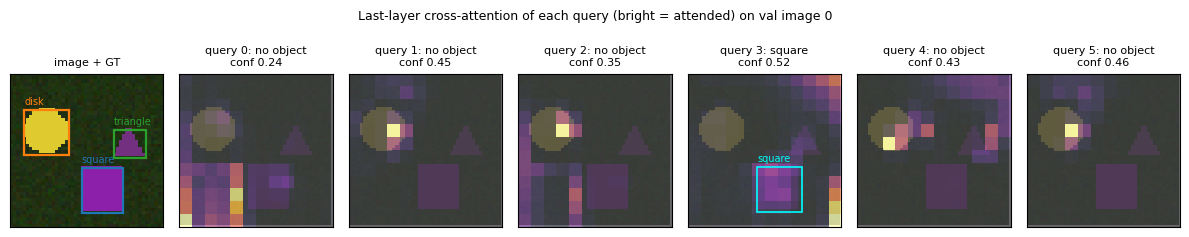

In [23]:
@torch.no_grad()
def cross_attention_maps(model, X):
    '''Run the model and return (preds, attn) with attn (n_images, N, h, w) from the last decoder layer.'''
    model.eval()
    logits, boxes = model(X.to(device))[-1]
    attn = model.dec[-1].last_cross                                       # (B, N, hw)
    h = w = int(math.sqrt(attn.shape[-1]))
    model.train()
    prob = logits.softmax(-1)
    s, c = prob[:, :, :K].max(-1)
    return (boxes.detach().cpu(), c.detach().cpu(), s.detach().cpu()), attn.reshape(len(X), -1, h, w).detach().cpu()

(cb, cc, cs), attn_va = cross_attention_maps(detr, Xva[:6])
print('cross-attention tensor:', tuple(attn_va.shape), '(images, queries, h, w); each map sums to', f'{attn_va[0, 0].sum():.3f}')

img_id = 0
fig, axes = plt.subplots(1, detr.n_queries + 1, figsize=(12, 2.3))
axes[0].imshow(Xva[img_id].permute(1, 2, 0).numpy()); draw_boxes(axes[0], Bva[img_id], Lva[img_id]); axes[0].set_title('image + GT', fontsize=8)
for q in range(detr.n_queries):
    ax = axes[q + 1]
    ax.imshow(Xva[img_id].permute(1, 2, 0).numpy(), alpha=0.5)
    ax.imshow(attn_va[img_id, q].numpy(), cmap='inferno', alpha=0.6, extent=(0, IMG, IMG, 0))
    lab = CLASS_NAMES[int(cc[img_id, q])] if cs[img_id, q] > 0.5 else 'no object'
    if cs[img_id, q] > 0.5:
        draw_boxes(ax, cb[img_id, q][None], [int(cc[img_id, q])], color='cyan', lw=1.2)
    ax.set_title(f'query {q}: {lab}\nconf {cs[img_id, q]:.2f}', fontsize=8)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Last-layer cross-attention of each query (bright = attended) on val image 0', y=1.05, fontsize=9)
plt.tight_layout(); plt.show()

### Widget 4: cross-attention per query

The maps for the first six validation images are precomputed above, so the slider only indexes. Pick an `image` and step through `query`: the queries that fire put their attention on the object they predict. On images where the model has produced a duplicate (section 5 counted them), you will find two queries with almost the same attention map and almost the same box; the "unique predictions" the slide promises are what the bipartite matching pushes toward, and after 900 steps our tiny model is still on its way there.

In [24]:
def attention_explorer(image=0, query=0):
    fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.6))
    axes[0].imshow(Xva[image].permute(1, 2, 0).numpy()); draw_boxes(axes[0], Bva[image], Lva[image])
    axes[0].set_title('image with ground truth', fontsize=9)
    axes[1].imshow(Xva[image].permute(1, 2, 0).numpy(), alpha=0.5)
    axes[1].imshow(attn_va[image, query].numpy(), cmap='inferno', alpha=0.65, extent=(0, IMG, IMG, 0))
    if cs[image, query] > 0.5:
        draw_boxes(axes[1], cb[image, query][None], [int(cc[image, query])], scores=[cs[image, query]], color='cyan')
        axes[1].set_title(f'query {query} predicts {CLASS_NAMES[int(cc[image, query])]} ({cs[image, query]:.2f})', fontsize=9)
    else:
        axes[1].set_title(f'query {query} predicts no object (conf {cs[image, query]:.2f})', fontsize=9)
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()

interact(attention_explorer,
         image=IntSlider(min=0, max=5, step=1, value=0, description='image'),
         query=IntSlider(min=0, max=detr.n_queries - 1, step=1, value=0, description='query'));

interactive(children=(IntSlider(value=0, description='image', max=5), IntSlider(value=0, description='query', …

## 7. Limitations of DETR, measured

The limitations slide lists three problems. Each is a claim we can test on our own model.

**Computational cost.** "DETR demands significant computational resources due to the quadratic complexity of the self-attention mechanism, making it impractical to handle high-resolution feature maps." The "why go beyond DETR" slide gives the complexity of multi-head attention as $O(N_q C^2 + N_k C^2 + N_q N_k C)$; in the encoder $N_q = N_k = HW$, so the last term is quadratic in the number of pixels. We time dense attention over feature maps from $8 \times 8$ to $48 \times 48$ tokens.

**Long training schedules and instability.** "Initially, almost equal attention weights of $1/N_k$ are set to all pixels." Softmax over $N_k$ keys with random projections gives nearly uniform weights, so the gradient that would tell a query which pixel matters is spread thin. We measure the entropy of the attention maps at initialization against the uniform value $\log N_k$, and again after training.

**Limited performance on small objects.** We split the validation objects by box side (small: under 12 pixels, large: 12 pixels and over) and evaluate matched IoU and AP50 on each group. As in COCO's area-range evaluation, the objects outside the range are **ignored rather than removed**: `evaluate` still matches every prediction against every object, and a prediction that claims an object of the other size group is neither a true positive nor a false positive. Without that rule the confident detections of large objects would sit at the top of the small-object ranking and depress its precision through no fault of the model.

     map  tokens  dense attn ms  attn matrix entries
  8x8         64          0.049                4,096
 12x12       144          0.051               20,736
 16x16       256          0.108               65,536
 24x24       576          0.475              331,776
 32x32      1024          1.191            1,048,576
 48x48      2304          5.858            5,308,416
log-log slope of time vs tokens: 1.80 fitted from 16x16 up, 1.96 between the two largest maps  (2.0 = exactly quadratic)
untrained: encoder self-attn entropy 4.96, decoder cross-attn entropy 4.95, mean max cross-attn weight 0.011   (uniform: entropy log 144 = 4.97, weight 1/144 = 0.0069)


  trained: encoder self-attn entropy 4.00, decoder cross-attn entropy 3.68, mean max cross-attn weight 0.137   (uniform: entropy log 144 = 4.97, weight 1/144 = 0.0069)



small objects (side < 12 px, n=156): matched IoU 0.654, AP50 0.342
large objects (side >= 12 px, n=228): matched IoU 0.815, AP50 0.566


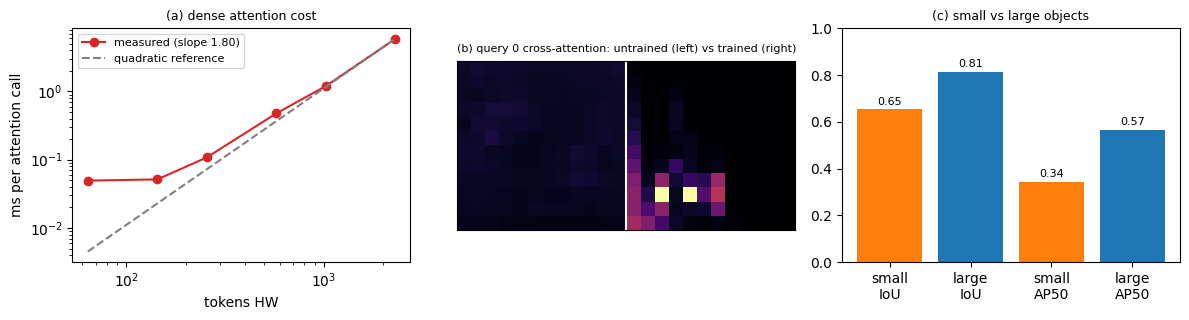

In [25]:
# (a) dense attention time grows quadratically with the number of tokens
def time_dense_attention(hw, C=64, heads=4, reps=5):
    q = torch.randn(1, heads, hw, C // heads, device=device); k, v = torch.randn_like(q), torch.randn_like(q)
    F.scaled_dot_product_attention(q, k, v)
    if device.type == 'cuda': torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(reps):
        F.scaled_dot_product_attention(q, k, v)
    if device.type == 'cuda': torch.cuda.synchronize()
    return (time.perf_counter() - t0) / reps * 1000

sides = [8, 12, 16, 24, 32, 48]
tokens = [s * s for s in sides]
ms_dense = [time_dense_attention(t) for t in tokens]
slope = np.polyfit(np.log(tokens[2:]), np.log(ms_dense[2:]), 1)[0]
print(f'{"map":>8} {"tokens":>7} {"dense attn ms":>14} {"attn matrix entries":>20}')
for s, t, m in zip(sides, tokens, ms_dense):
    print(f'{s:>3}x{s:<4} {t:>7} {m:>14.3f} {t * t:>20,}')
local = math.log(ms_dense[-1] / ms_dense[-2]) / math.log(tokens[-1] / tokens[-2])
print(f'log-log slope of time vs tokens: {slope:.2f} fitted from 16x16 up, {local:.2f} between the two largest maps  (2.0 = exactly quadratic)')

# (b) attention is nearly uniform at initialization: entropy close to log(N_k)
@torch.no_grad()
def attention_entropy(model, X):
    model.eval(); model(X.to(device)); model.train()
    enc_w = model.enc[-1].last_attn                                       # (B, HW, HW)
    dec_w = model.dec[-1].last_cross                                      # (B, N, HW)
    ent = lambda w: -(w * (w + 1e-12).log()).sum(-1).mean().item()
    return ent(enc_w), dec_w.max(-1).values.mean().item(), ent(dec_w)

set_seed(0)
fresh = TinyDETR().to(device)
Nk = 144
for name, m in [('untrained', fresh), ('trained', detr)]:
    e_enc, mx_dec, e_dec = attention_entropy(m, Xva[:32])
    print(f'{name:>9}: encoder self-attn entropy {e_enc:.2f}, decoder cross-attn entropy {e_dec:.2f}, '
          f'mean max cross-attn weight {mx_dec:.3f}   (uniform: entropy log {Nk} = {math.log(Nk):.2f}, weight 1/{Nk} = {1 / Nk:.4f})')

# (c) small objects are harder
miou_small, ap_small = evaluate(detr, Xva, Bva, Lva, size_range=(0, 12))
miou_large, ap_large = evaluate(detr, Xva, Bva, Lva, size_range=(12, 100))
n_small = sum(int(((b[:, 2] * IMG) < 12).sum()) for b in Bva); n_large = sum(len(b) for b in Bva) - n_small
print(f'\nsmall objects (side < 12 px, n={n_small}): matched IoU {miou_small:.3f}, AP50 {ap_small:.3f}')
print(f'large objects (side >= 12 px, n={n_large}): matched IoU {miou_large:.3f}, AP50 {ap_large:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
axes[0].loglog(tokens, ms_dense, 'o-', color='#d62728', label=f'measured (slope {slope:.2f})')
axes[0].loglog(tokens, [ms_dense[-1] * (t / tokens[-1]) ** 2 for t in tokens], '--', color='gray', label='quadratic reference')
axes[0].set_xlabel('tokens HW'); axes[0].set_ylabel('ms per attention call'); axes[0].legend(fontsize=8); axes[0].set_title('(a) dense attention cost', fontsize=9)
w_fresh = fresh.dec[-1].last_cross[0, 0].reshape(12, 12).cpu().numpy(); w_train = detr.dec[-1].last_cross[0, 0].reshape(12, 12).cpu().numpy()
axes[1].imshow(np.concatenate([w_fresh, w_train], axis=1), cmap='inferno'); axes[1].axvline(11.5, color='w')
axes[1].set_title('(b) query 0 cross-attention: untrained (left) vs trained (right)', fontsize=8); axes[1].set_xticks([]); axes[1].set_yticks([])
axes[2].bar(['small\nIoU', 'large\nIoU', 'small\nAP50', 'large\nAP50'], [miou_small, miou_large, ap_small, ap_large],
            color=['#ff7f0e', '#1f77b4', '#ff7f0e', '#1f77b4']); axes[2].set_ylim(0, 1); axes[2].set_title('(c) small vs large objects', fontsize=9)
for i, v in enumerate([miou_small, miou_large, ap_small, ap_large]):
    axes[2].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

## 8. Deformable DETR: deformable attention

*Zhu et al., Deformable DETR: Deformable Transformers for End-to-End Object Detection, ICLR 2021.* The slide poses the question and the answer in one line each:

> "Question: How can we reduce the quadratic computational complexity of self-attention?"
> "Deformable DETR: For a given pixel, only attend to a few key points around it instead of attending to every other pixel in the image."

Multi-head attention (the slide's Eq. 2) is $\mathrm{MultiHeadAttn}(z_q, x) = \sum_{m=1}^{M} W_m \big[\sum_{k \in \Omega_k} A_{mqk} \cdot W'_m x_k\big]$, a weighted sum over **all** keys, with the weights $A_{mqk}$ computed by a dot product. Deformable attention (Eq. 3) keeps the outer structure but replaces the sum over all keys by a sum over $K \ll HW$ **sampled points** near a reference point $p_q$:

$$\mathrm{DeformAttn}(z_q, p_q, x) = \sum_{m=1}^{M} W_m \Big[ \sum_{k=1}^{K} A_{mqk} \cdot W'_m\, x\big(p_q + \Delta p_{mqk}\big) \Big].$$

Three things changed, and all three come straight from the query feature $z_q$ through linear layers:

- the **sampling offsets** $\Delta p_{mqk}$ are predicted, not searched for (a linear layer of $z_q$ outputs $2MK$ numbers);
- the **attention weights** $A_{mqk}$ are also predicted from $z_q$ by a linear layer followed by a softmax over the $K$ points, with no query-key dot product at all;
- $x(p_q + \Delta p)$ is read off the feature map at a fractional position by **bilinear interpolation**, which is what `F.grid_sample` does.

The slide gives the complexity as $O(2 N_q C^2 + \min(HWC^2, N_q K C^2))$: linear in $HW$ for the encoder (where $N_q = HW$) and independent of the spatial size for the decoder. There is no $N_q N_k$ term because no query ever compares itself against every key.

### 8a. A single-scale deformable attention module

Two details from the paper's implementation: the offset layer starts at zero weights with a bias that fans the $K$ points of head $m$ out along direction $2\pi m / M$ at distances $1, 2, \dots, K$ pixels, and the attention-weight layer starts at zero (uniform weights over the $K$ points). We first verify that `grid_sample` computes the bilinear interpolation we think it does.

In [26]:
def bilinear_scratch(feat, pts):
    '''Bilinear interpolation by hand. feat (C,H,W); pts (P,2) as normalized (x,y) in [0,1]; zero outside.'''
    C, H, W = feat.shape
    x, y = pts[:, 0] * W - 0.5, pts[:, 1] * H - 0.5                       # pixel centres at half-integers
    x0, y0 = x.floor(), y.floor(); wx, wy = x - x0, y - y0
    out = torch.zeros(C, len(pts))
    for dx, dy, wgt in [(0, 0, (1 - wx) * (1 - wy)), (1, 0, wx * (1 - wy)), (0, 1, (1 - wx) * wy), (1, 1, wx * wy)]:
        xi, yi = (x0 + dx).long(), (y0 + dy).long()
        ok = (xi >= 0) & (xi < W) & (yi >= 0) & (yi < H)
        v = torch.zeros(C, len(pts)); v[:, ok] = feat[:, yi[ok], xi[ok]]
        out += v * wgt
    return out

def sample_points(feat, pts):
    '''feat (C,H,W), pts (P,2) normalized (x,y) in [0,1] -> (C,P) via F.grid_sample (align_corners=False).'''
    grid = (pts * 2 - 1)[None, None]                                    # (1,1,P,2) in [-1,1]
    return F.grid_sample(feat[None], grid, mode='bilinear', padding_mode='zeros', align_corners=False)[0, :, 0]

set_seed(0)
feat = torch.randn(3, 6, 8); pts = torch.rand(25, 2) * 1.2 - 0.1         # some points fall outside the map
assert torch.allclose(sample_points(feat, pts), bilinear_scratch(feat, pts), atol=1e-5)
print(f'F.grid_sample vs bilinear interpolation by hand: max |diff| = {(sample_points(feat, pts) - bilinear_scratch(feat, pts)).abs().max():.1e}')

class DeformAttn(nn.Module):
    '''Single-scale deformable attention (the slide's Eq. 3). Queries carry a reference point each.'''
    def __init__(self, d=64, heads=4, points=4):
        super().__init__()
        self.d, self.M, self.K = d, heads, points
        self.value_proj = nn.Linear(d, d)                                 # W'_m for all heads at once
        self.offsets = nn.Linear(d, heads * points * 2)                   # Delta p_{mqk}
        self.attn_logits = nn.Linear(d, heads * points)                   # A_{mqk} before the softmax over k
        self.out_proj = nn.Linear(d, d)                                   # W_m
        nn.init.zeros_(self.offsets.weight); nn.init.zeros_(self.attn_logits.weight); nn.init.zeros_(self.attn_logits.bias)
        angles = torch.arange(heads) * 2 * math.pi / heads               # paper's init: head m looks along angle 2 pi m / M
        base = torch.stack([angles.cos(), angles.sin()], -1)              # (M, 2)
        base = base[:, None, :] * torch.arange(1, points + 1)[None, :, None]   # (M, K, 2) at distances 1..K pixels
        with torch.no_grad():
            self.offsets.bias.copy_(base.flatten())

    def forward(self, z, ref, x):
        '''z: (B,Nq,d) query features; ref: (B,Nq,2) reference points normalized (x,y); x: (B,d,H,W) feature map.'''
        B, Nq, _ = z.shape; H, W = x.shape[-2:]; M, K, dh = self.M, self.K, self.d // self.M
        v = self.value_proj(x.flatten(2).transpose(1, 2)).reshape(B, H * W, M, dh)     # W'_m x_k
        v = v.permute(0, 2, 3, 1).reshape(B * M, dh, H, W)                               # one map per head
        off = self.offsets(z).reshape(B, Nq, M, K, 2)                                    # in pixels
        loc = ref[:, :, None, None, :] + off / torch.tensor([W, H], device=z.device)     # p_q + Delta p, normalized
        A = self.attn_logits(z).reshape(B, Nq, M, K).softmax(-1)                             # A_{mqk}, sums to 1 over k
        grid = (loc.permute(0, 2, 1, 3, 4).reshape(B * M, Nq, K, 2) * 2 - 1)
        sampled = F.grid_sample(v, grid, mode='bilinear', padding_mode='zeros', align_corners=False)   # (B*M, dh, Nq, K)
        out = (sampled * A.permute(0, 2, 1, 3).reshape(B * M, 1, Nq, K)).sum(-1)                        # sum_k A * x(p)
        out = out.reshape(B, M, dh, Nq).permute(0, 3, 1, 2).reshape(B, Nq, M * dh)
        self.last_locations, self.last_A = loc.detach(), A.detach()
        return self.out_proj(out)

set_seed(0)
dattn = DeformAttn().to(device)
with torch.no_grad():
    fmap = detr.backbone(Xva[:2].to(device))                            # (2, 64, 12, 12) real features
    B_, C_, H_, W_ = fmap.shape
    yy, xx = torch.meshgrid(torch.arange(H_), torch.arange(W_), indexing='ij')
    ref_all = ((torch.stack([xx, yy], -1).reshape(-1, 2).float() + 0.5) / torch.tensor([W_, H_]))[None].expand(B_, -1, -1).to(device)
    z_all = fmap.flatten(2).transpose(1, 2)                             # encoder use: every pixel is a query
    y = dattn(z_all, ref_all, fmap)
print(f'encoder-style deformable attention: queries {tuple(z_all.shape)} -> output {tuple(y.shape)}; '
      f'each query touched {dattn.M} heads x {dattn.K} points = {dattn.M * dattn.K} samples instead of {H_ * W_} keys')
print(f'parameters: DeformAttn {count_params(dattn):,} vs nn.MultiheadAttention {count_params(nn.MultiheadAttention(64, 4)):,}')

F.grid_sample vs bilinear interpolation by hand: max |diff| = 1.6e-07
encoder-style deformable attention: queries (2, 144, 64) -> output (2, 144, 64); each query touched 4 heads x 4 points = 16 samples instead of 144 keys
parameters: DeformAttn 11,440 vs nn.MultiheadAttention 16,640


### 8b. The cost, by the slide's formulas and by the clock

The slide's two complexity expressions, evaluated for our $C = 64$, $M K = 16$ samples per query and encoder use ($N_q = N_k = HW$), plus the measured time of one call of each module on the same feature map sizes. FLOP counts scale as the formulas say; wall-clock on a CPU includes the overhead of `grid_sample`, so the crossover happens later than the formulas suggest, which is honest to report.

     map  tokens   dense FLOPs  deform FLOPs   ratio  dense ms  deform ms
  8x8         64      7.86e+05      7.86e+05     1.0     0.049      0.138
 12x12       144      2.51e+06      1.77e+06     1.4     0.051      0.178
 16x16       256      6.29e+06      3.15e+06     2.0     0.108      0.244
 24x24       576      2.60e+07      7.08e+06     3.7     0.475      0.422
 32x32      1024      7.55e+07      1.26e+07     6.0     1.191      0.493
 48x48      2304      3.59e+08      2.83e+07    12.7     5.858      0.715


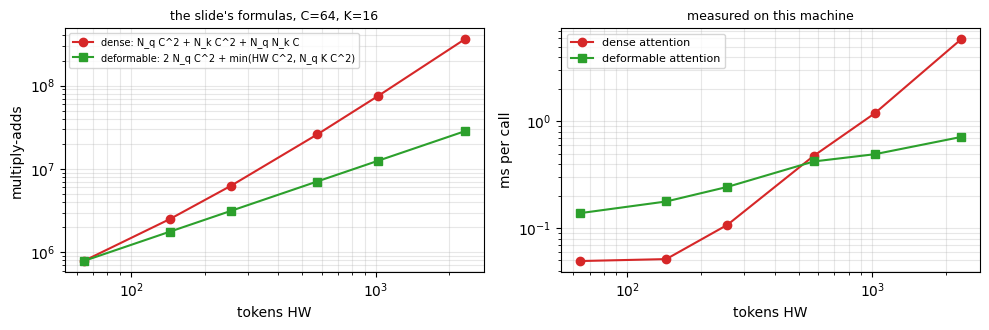

In [27]:
def flops_dense(hw, C=64):
    return hw * C * C + hw * C * C + hw * hw * C                           # N_q C^2 + N_k C^2 + N_q N_k C

def flops_deform(hw, C=64, K=16):
    return 2 * hw * C * C + min(hw * C * C, hw * K * C * C)               # 2 N_q C^2 + min(HW C^2, N_q K C^2)

def time_deform_attention(side, reps=5):
    x = torch.randn(1, 64, side, side, device=device)
    yy, xx = torch.meshgrid(torch.arange(side), torch.arange(side), indexing='ij')
    ref = ((torch.stack([xx, yy], -1).reshape(-1, 2).float() + 0.5) / side)[None].to(device)
    z = x.flatten(2).transpose(1, 2)
    with torch.no_grad():
        dattn(z, ref, x)
        t0 = time.perf_counter()
        for _ in range(reps):
            dattn(z, ref, x)
    return (time.perf_counter() - t0) / reps * 1000

ms_deform = [time_deform_attention(s) for s in sides]
print(f'{"map":>8} {"tokens":>7} {"dense FLOPs":>13} {"deform FLOPs":>13} {"ratio":>7} {"dense ms":>9} {"deform ms":>10}')
for s, t, md_, mf in zip(sides, tokens, ms_dense, ms_deform):
    print(f'{s:>3}x{s:<4} {t:>7} {flops_dense(t):>13.2e} {flops_deform(t):>13.2e} {flops_dense(t) / flops_deform(t):>7.1f} {md_:>9.3f} {mf:>10.3f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].loglog(tokens, [flops_dense(t) for t in tokens], 'o-', color='#d62728', label='dense: N_q C^2 + N_k C^2 + N_q N_k C')
axes[0].loglog(tokens, [flops_deform(t) for t in tokens], 's-', color='#2ca02c', label='deformable: 2 N_q C^2 + min(HW C^2, N_q K C^2)')
axes[0].set_xlabel('tokens HW'); axes[0].set_ylabel('multiply-adds'); axes[0].legend(fontsize=7); axes[0].set_title("the slide's formulas, C=64, K=16", fontsize=9)
axes[1].loglog(tokens, ms_dense, 'o-', color='#d62728', label='dense attention'); axes[1].loglog(tokens, ms_deform, 's-', color='#2ca02c', label='deformable attention')
axes[1].set_xlabel('tokens HW'); axes[1].set_ylabel('ms per call'); axes[1].legend(fontsize=8); axes[1].set_title('measured on this machine', fontsize=9)
for ax in axes: ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

### 8c. Multi-scale deformable attention

The multi-scale slide extends Eq. 3 to a feature pyramid $\{x^l\}_{l=1}^{L}$:

$$\mathrm{MSDeformAttn}(z_q, \hat p_q, \{x^l\}) = \sum_{m=1}^{M} W_m \Big[\sum_{l=1}^{L} \sum_{k=1}^{K} A_{mlqk} \cdot W'_m\, x^l\big(\phi_l(\hat p_q) + \Delta p_{mlqk}\big)\Big].$$

The reference point $\hat p_q$ is now **normalized** to $[0,1]^2$, and $\phi_l$ rescales it to the resolution of level $l$. Because `grid_sample` takes normalized coordinates, $\phi_l$ is free; only the offsets, which are in pixels of their own level, need dividing by $(W_l, H_l)$. The softmax over attention weights now runs over all $LK$ points, so a query can decide how much to read from the fine level and how much from the coarse one. This is Deformable DETR's answer to small objects: adding a fine level adds no sampling work because the number of samples per query is fixed. One cost does still grow with the map: the value projection $W'_m x^l$, which our implementation (like the encoder) applies to every token of every level, an $O(HWC^2)$ term. The paper's decoder gets its $O(N_q K C^2)$ term by projecting only the sampled points when that is cheaper, which is the $\min$ in the slide's formula; the timing below makes the difference visible. We build a two-level version by adding a stride-2 pooled copy of our feature map.

In [28]:
class MSDeformAttn(nn.Module):
    '''Multi-scale deformable attention over L feature levels; softmax over all L*K points per head.'''
    def __init__(self, d=64, heads=4, levels=2, points=4):
        super().__init__()
        self.d, self.M, self.L, self.K = d, heads, levels, points
        self.value_proj, self.out_proj = nn.Linear(d, d), nn.Linear(d, d)
        self.offsets = nn.Linear(d, heads * levels * points * 2)
        self.attn_logits = nn.Linear(d, heads * levels * points)
        nn.init.zeros_(self.offsets.weight); nn.init.zeros_(self.attn_logits.weight); nn.init.zeros_(self.attn_logits.bias)
        angles = torch.arange(heads) * 2 * math.pi / heads
        base = torch.stack([angles.cos(), angles.sin()], -1)[:, None, None, :] * torch.arange(1, points + 1)[None, None, :, None]
        with torch.no_grad():
            self.offsets.bias.copy_(base.expand(heads, levels, points, 2).flatten())

    def forward(self, z, ref, xs):
        '''z (B,Nq,d); ref (B,Nq,2) normalized; xs: list of L maps (B,d,H_l,W_l).'''
        B, Nq, _ = z.shape; M, L, K, dh = self.M, self.L, self.K, self.d // self.M
        off = self.offsets(z).reshape(B, Nq, M, L, K, 2)
        A = self.attn_logits(z).reshape(B, Nq, M, L * K).softmax(-1).reshape(B, Nq, M, L, K)
        out = 0
        for l, x in enumerate(xs):
            H, W = x.shape[-2:]
            v = self.value_proj(x.flatten(2).transpose(1, 2)).reshape(B, H * W, M, dh).permute(0, 2, 3, 1).reshape(B * M, dh, H, W)
            loc = ref[:, :, None, None, :] + off[:, :, :, l] / torch.tensor([W, H], device=z.device)   # phi_l is the identity in normalized coords
            grid = loc.permute(0, 2, 1, 3, 4).reshape(B * M, Nq, K, 2) * 2 - 1
            s = F.grid_sample(v, grid, mode='bilinear', padding_mode='zeros', align_corners=False)
            out = out + (s * A[:, :, :, l].permute(0, 2, 1, 3).reshape(B * M, 1, Nq, K)).sum(-1)
        out = out.reshape(B, M, dh, Nq).permute(0, 3, 1, 2).reshape(B, Nq, M * dh)
        return self.out_proj(out)

set_seed(0)
ms_attn = MSDeformAttn().to(device)
with torch.no_grad():
    x1 = fmap                                                            # level 1: 12x12
    x2 = F.avg_pool2d(fmap, 2)                                           # level 2: 6x6
    q_ref = torch.tensor([[[0.25, 0.25], [0.5, 0.5], [0.8, 0.6]]]).expand(B_, -1, -1).to(device)   # 3 decoder-style queries
    z_q = torch.randn(B_, 3, 64, device=device)
    y_ms = ms_attn(z_q, q_ref, [x1, x2])
print(f'levels: {tuple(x1.shape[-2:])} and {tuple(x2.shape[-2:])}; 3 queries -> output {tuple(y_ms.shape)}; '
      f'{ms_attn.M * ms_attn.L * ms_attn.K} samples per query regardless of the map sizes')
# the sample count per query is fixed, but this implementation still projects every token of every level (value_proj on
# all HW), so its time does depend on the map size; time the same 3 queries on the 12x12/6x6 maps and on 4x larger maps
def time_ms_attn(maps, reps=20):
    with torch.no_grad():
        ms_attn(z_q, q_ref, maps)
        t0 = time.perf_counter()
        for _ in range(reps):
            ms_attn(z_q, q_ref, maps)
    return (time.perf_counter() - t0) / reps * 1000

with torch.no_grad():
    big = [F.interpolate(x1, scale_factor=4, mode='bilinear', align_corners=False), F.interpolate(x2, scale_factor=4, mode='bilinear', align_corners=False)]
    y_big = ms_attn(z_q, q_ref, big)
ms_small, ms_big = time_ms_attn([x1, x2]), time_ms_attn(big)
print(f'on 4x larger maps {tuple(big[0].shape[-2:])} / {tuple(big[1].shape[-2:])}: output {tuple(y_big.shape)}, still {ms_attn.M * ms_attn.L * ms_attn.K} samples per query,')
print(f'  but {ms_small:.2f} ms -> {ms_big:.2f} ms per call ({ms_big / ms_small:.1f}x): the value projection here touches every token, an O(HW C^2) term over 16x more tokens.')
print("  The paper's O(N_q K C^2) decoder cost needs projecting only the M L K sampled points of each query, not the whole map.")

levels: (12, 12) and (6, 6); 3 queries -> output (2, 3, 64); 32 samples per query regardless of the map sizes
on 4x larger maps (48, 48) / (24, 24): output (2, 3, 64), still 32 samples per query,
  but 0.14 ms -> 0.35 ms per call (2.4x): the value projection here touches every token, an O(HW C^2) term over 16x more tokens.
  The paper's O(N_q K C^2) decoder cost needs projecting only the M L K sampled points of each query, not the whole map.


### 8d. Iterative bounding box refinement and the two-stage variant

Two further improvements from the slides need no new module, only a different wiring of the decoder:

- **Iterative bounding box refinement.** Each decoder layer predicts a box *update* $\Delta b$ relative to the box from the previous layer, and the refined box also becomes the next layer's reference point $\hat p_q$, so the sampling points follow the object as the estimate improves. Deformable DETR detaches the box between layers to stabilise training; DINO revisits exactly this choice in section 9.
- **Two-stage Deformable DETR.** Instead of learned queries, the encoder output itself proposes regions: every encoder token predicts a box and an objectness score, the top-$K$ proposals become the decoder's queries (their boxes are the reference points, their features the content), and the decoder refines them. This is "inspired by two-stage object detectors", the region-proposal idea of Faster R-CNN reborn inside a transformer.

### 8e. Where does a query sample? The static sweep

For four reference points on the feature map of validation image 0 we draw the $M K = 16$ sampling locations of the single-scale module, one color per head, marker size proportional to $A_{mqk}$. With the paper's initialization the offsets are the fixed fan of arrows; with a random offset layer (standing in for a trained one) they depend on the content $z_q$ at the reference point.

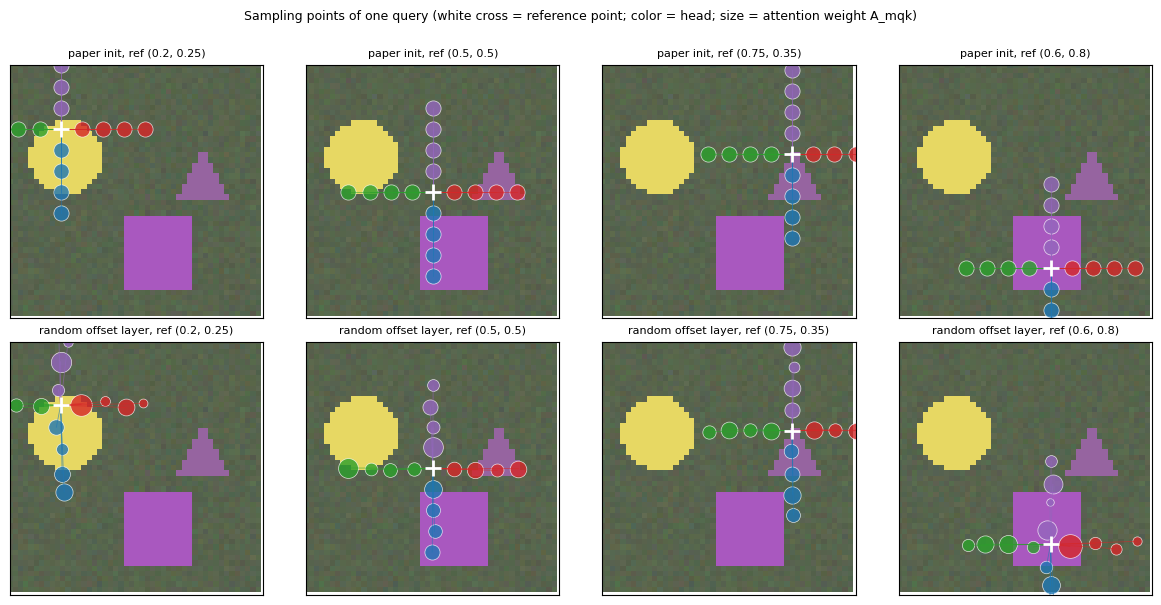

In [29]:
set_seed(1)
dattn_rand = DeformAttn().to(device)                                     # a second module with query-dependent offsets
nn.init.normal_(dattn_rand.offsets.weight, std=0.05); nn.init.normal_(dattn_rand.attn_logits.weight, std=0.5)
HEAD_COLORS = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd']

@torch.no_grad()
def sampling_points(module, ref_xy, image=0):
    '''Sampling locations (M,K,2) in pixels and weights (M,K) for one query at normalized ref_xy on val image `image`.'''
    x = detr.backbone(Xva[image:image + 1].to(device))
    ref = torch.tensor([[ref_xy]], device=device, dtype=torch.float32)
    z = sample_points(x[0], ref[0])[None].transpose(1, 2)                # content at the reference point, (1,1,d)
    module(z, ref, x)
    loc = module.last_locations[0, 0].cpu() * IMG                        # (M,K,2) in image pixels
    return loc, module.last_A[0, 0].cpu()

def draw_sampling(ax, module, ref_xy, image=0, heads='all', title=None):
    ax.imshow(Xva[image].permute(1, 2, 0).numpy(), alpha=0.75)
    loc, A = sampling_points(module, ref_xy, image)
    for m in range(loc.shape[0]):
        if heads != 'all' and m != heads: continue
        for k in range(loc.shape[1]):
            ax.plot([ref_xy[0] * IMG, loc[m, k, 0]], [ref_xy[1] * IMG, loc[m, k, 1]], color=HEAD_COLORS[m], lw=0.6, alpha=0.6)
            ax.scatter(loc[m, k, 0], loc[m, k, 1], s=20 + 400 * A[m, k].item(), color=HEAD_COLORS[m], alpha=0.8, edgecolor='w', lw=0.5)
    ax.plot(ref_xy[0] * IMG, ref_xy[1] * IMG, 'w+', ms=12, mew=2)
    ax.set_xlim(0, IMG); ax.set_ylim(IMG, 0); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title or f'reference ({ref_xy[0]:.2f}, {ref_xy[1]:.2f})', fontsize=8)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for j, r in enumerate([(0.2, 0.25), (0.5, 0.5), (0.75, 0.35), (0.6, 0.8)]):
    draw_sampling(axes[0, j], dattn, r, title=f'paper init, ref {r}')
    draw_sampling(axes[1, j], dattn_rand, r, title=f'random offset layer, ref {r}')
plt.suptitle('Sampling points of one query (white cross = reference point; color = head; size = attention weight A_mqk)', y=1.0, fontsize=9)
plt.tight_layout(); plt.show()

### Widget 5: the deformable sampling points viewer

Move the reference point with `x` and `y`, choose a `head` (or all four), and switch `offsets` between the paper's initialization and the random offset layer. With the initial pattern the 16 points are a rigid fan that follows the reference point; with the random layer, moving the reference across an object edge changes the content $z_q$ and therefore where the points land and how they are weighted. Sampling points falling outside the image read zeros.

In [30]:
def deform_explorer(x=0.5, y=0.5, head='all', offsets='paper init'):
    module = dattn if offsets == 'paper init' else dattn_rand
    fig, ax = plt.subplots(figsize=(4.6, 4.4))
    draw_sampling(ax, module, (x, y), heads='all' if head == 'all' else int(head),
                  title=f'{offsets}, head {head}, reference ({x:.2f}, {y:.2f})')
    plt.tight_layout(); plt.show()

interact(deform_explorer,
         x=FloatSlider(min=0.05, max=0.95, step=0.05, value=0.5, description='x'),
         y=FloatSlider(min=0.05, max=0.95, step=0.05, value=0.5, description='y'),
         head=Dropdown(options=['all', '0', '1', '2', '3'], value='all', description='head'),
         offsets=Dropdown(options=['paper init', 'random layer'], value='paper init', description='offsets'));

interactive(children=(FloatSlider(value=0.5, description='x', max=0.95, min=0.05, step=0.05), FloatSlider(valu…

## 9. DINO: denoising anchor boxes

*Zhang et al., DINO: DETR with Improved DeNoising Anchor Boxes for End-to-End Object Detection, ICLR 2023.* The "improving DETR" slides list the line of work DINO builds on:

- **DAB-DETR** (*Liu et al., ICLR 2022*) formulates the queries as dynamic anchor boxes $(x, y, w, h)$ that each decoder layer refines, bridging anchor-based detectors and DETR.
- **DN-DETR** (*Li et al., CVPR 2022*) attacks the instability of bipartite matching with a **denoising** task.
- DINO combines them with deformable attention and adds three ideas of its own: **contrastive denoising**, **mixed query selection** and **look forward twice**.

### 9a. Denoising training, implemented on the tiny DETR

The instability DN-DETR targets is easy to state: early in training the predictions are poor, so the Hungarian matching flips from step to step, and a query is asked to regress toward a different object each time. Denoising training adds a second, **stable** task in the same forward pass:

1. Take the ground-truth boxes of the image, add noise (shift the centre by up to $\lambda$ of the box size, scale the width and height by up to $\lambda$) and, with some probability, flip the label.
2. Turn every noisy pair into a query: content from the (noisy) label embedding, position from a sinusoidal embedding of the noisy box. Append these **denoising queries** to the $N$ matching queries.
3. Train the denoising queries to **reconstruct the clean box and label**, with no matching at all: the target of each denoising query is known by construction.
4. Mask the decoder self-attention so that the matching queries cannot see the denoising queries (that would leak the answer), and denoising groups cannot see each other.

`make_dn_queries` builds the queries and the mask, `dn_loss` is the reconstruction loss, and `TinyDETR.forward` already accepts the result through its `dn` argument. We then train a second model, identical to `detr` in every other respect (same seed, same batches, same schedule, again in two halves), and compare the two curves.

denoising queries per image: (2, 6, 4) | valid slots per image: [6, 2] | mask: (8, 12, 12) (batch x heads, 12 queries, 12 queries)


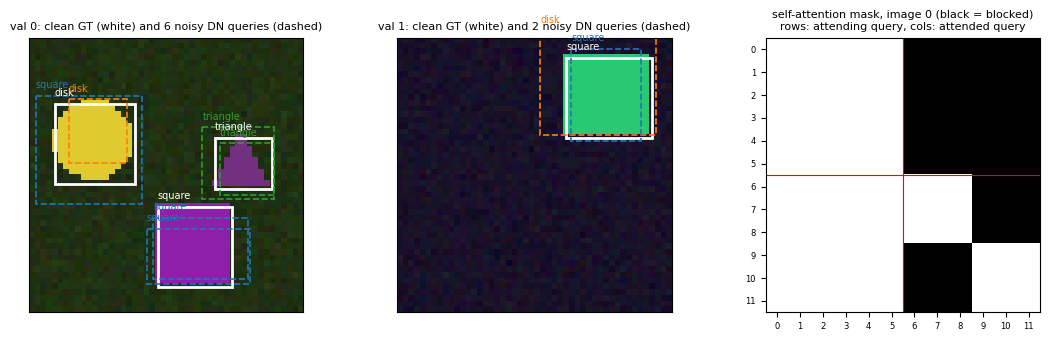

In [31]:
def make_dn_queries(tgt_labels, tgt_boxes, n_queries, groups=2, box_noise=0.4, label_noise=0.2, max_obj=3, heads=4):
    '''Noisy copies of the ground truth as extra queries, plus the decoder self-attention mask.
    Returns a dict with labels (B,n_dn), boxes (B,n_dn,4), mask (B*heads, L, L), valid (B,n_dn) and the clean targets.'''
    B, n_dn, dev = len(tgt_labels), groups * max_obj, tgt_boxes[0].device
    labels = torch.full((B, n_dn), NO_OBJ, dtype=torch.long, device=dev)
    boxes = torch.rand(B, n_dn, 4, device=dev) * 0.5 + 0.25              # padded slots get a dummy box, masked out below
    valid = torch.zeros(B, n_dn, dtype=torch.bool, device=dev)
    clean_labels = torch.full((B, n_dn), NO_OBJ, dtype=torch.long, device=dev)
    clean_boxes = torch.zeros(B, n_dn, 4, device=dev)
    for b in range(B):
        m, gt = len(tgt_labels[b]), tgt_boxes[b]
        for g in range(groups):
            s = g * max_obj
            noise = (torch.rand(m, 4, device=dev) * 2 - 1) * box_noise      # uniform in [-lambda, lambda]
            nb = gt.clone()
            nb[:, :2] += noise[:, :2] * gt[:, 2:] / 2                         # centre shift, relative to the box size
            nb[:, 2:] *= 1 + noise[:, 2:]                                     # width and height scaling
            lab = tgt_labels[b].clone()
            flip = torch.rand(m, device=dev) < label_noise
            lab[flip] = torch.randint(0, K, (int(flip.sum()),), device=dev)
            labels[b, s:s + m], boxes[b, s:s + m], valid[b, s:s + m] = lab, nb.clamp(0.01, 0.99), True
            clean_labels[b, s:s + m], clean_boxes[b, s:s + m] = tgt_labels[b], gt
    L = n_queries + n_dn
    mask = torch.zeros(L, L, dtype=torch.bool, device=dev)                  # True = may NOT attend
    mask[:n_queries, n_queries:] = True                                     # matching part cannot see the DN part
    for g in range(groups):
        s = n_queries + g * max_obj
        mask[s:s + max_obj, n_queries:] = True                              # a DN group cannot see other groups ...
        mask[s:s + max_obj, s:s + max_obj] = False                          # ... but sees itself
    mask = mask[None].expand(B, -1, -1).clone()
    mask[:, :, n_queries:] |= ~valid[:, None, :]                            # nobody attends to padded slots
    return {'labels': labels, 'boxes': boxes, 'mask': mask.repeat_interleave(heads, 0), 'valid': valid,
            'clean_labels': clean_labels, 'clean_boxes': clean_boxes}

def dn_loss(logits, boxes, dn, eos_coef=0.1, w_l1=5.0, w_giou=2.0):
    '''Reconstruction loss on the denoising queries: no matching, the target of each query is its clean box and label.'''
    v = dn['valid']
    weight = torch.ones(K + 1, device=logits.device); weight[NO_OBJ] = eos_coef
    loss_ce = F.cross_entropy(logits[v], dn['clean_labels'][v], weight=weight)
    n = max(int(v.sum()), 1)
    loss_l1 = F.l1_loss(boxes[v], dn['clean_boxes'][v], reduction='sum') / n
    loss_giou = (1 - torch.diag(giou_scratch(box_cxcywh_to_xyxy(boxes[v]), box_cxcywh_to_xyxy(dn['clean_boxes'][v])))).sum() / n
    return loss_ce + w_l1 * loss_l1 + w_giou * loss_giou

set_seed(0)
dn = make_dn_queries([l.to(device) for l in Lva[:2]], [b.to(device) for b in Bva[:2]], n_queries=6)
print('denoising queries per image:', tuple(dn['boxes'].shape), '| valid slots per image:', dn['valid'].sum(1).tolist(),
      '| mask:', tuple(dn['mask'].shape), '(batch x heads, 12 queries, 12 queries)')

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for j in range(2):
    axes[j].imshow(Xva[j].permute(1, 2, 0).numpy())
    draw_boxes(axes[j], Bva[j], Lva[j], color='white', lw=2)
    v = dn['valid'][j]
    draw_boxes(axes[j], dn['boxes'][j][v].cpu(), dn['labels'][j][v].cpu(), ls='--', lw=1.2)
    axes[j].set_title(f'val {j}: clean GT (white) and {int(v.sum())} noisy DN queries (dashed)', fontsize=8); axes[j].set_xticks([]); axes[j].set_yticks([])
axes[2].imshow(dn['mask'][0].cpu().numpy(), cmap='Greys'); axes[2].set_title('self-attention mask, image 0 (black = blocked)\nrows: attending query, cols: attended query', fontsize=8)
axes[2].set_xticks(range(12)); axes[2].set_yticks(range(12)); axes[2].tick_params(labelsize=6)
axes[2].axhline(5.5, color='r', lw=0.8); axes[2].axvline(5.5, color='r', lw=0.8)
plt.tight_layout(); plt.show()

In [32]:
set_seed(0)
detr_dn = TinyDETR()
trainer_dn = DetrTrainer(detr_dn, STEPS, use_dn=True)
print(f'training tiny DETR + denoising queries for {STEPS} steps (same seed, data order and schedule as before), first half ...')
print(f'steps 0 to {STEPS // 2} done in {trainer_dn.run(STEPS // 2):.1f} s')

training tiny DETR + denoising queries for 900 steps (same seed, data order and schedule as before), first half ...
  step    0   val matched IoU 0.136   AP50 0.000   (  0.1 s)


  step  200   val matched IoU 0.373   AP50 0.011   (  8.5 s)


  step  400   val matched IoU 0.595   AP50 0.261   ( 17.0 s)


steps 0 to 450 done in 19.0 s


In [33]:
print('second half ...')
print(f'steps {STEPS // 2} to {STEPS} done in {trainer_dn.run(STEPS):.1f} s')
curve_dn, snaps_dn, t_dn = trainer_dn.curve, trainer_dn.snaps, trainer_dn.seconds
miou_dn, ap_dn = curve_dn[-1][1], curve_dn[-1][2]
print(f'total {t_dn:.1f} s of training and evaluation: matched mean IoU {miou_dn:.3f}, AP50 {ap_dn:.3f}')

second half ...


  step  600   val matched IoU 0.716   AP50 0.710   ( 25.4 s)


  step  800   val matched IoU 0.774   AP50 0.788   ( 33.9 s)


  step  900   val matched IoU 0.778   AP50 0.790   ( 38.2 s)
steps 450 to 900 done in 19.1 s
total 38.2 s of training and evaluation: matched mean IoU 0.778, AP50 0.790


In [34]:
print(f'{"step":>6} {"DETR AP50":>10} {"DETR+DN AP50":>13} {"DETR IoU":>9} {"DETR+DN IoU":>12}')
for (s, i1, a1), (_, i2, a2) in zip(curve_detr, curve_dn):
    print(f'{s:>6} {a1:>10.3f} {a2:>13.3f} {i1:>9.3f} {i2:>12.3f}')
first = lambda curve, thr: next((str(s) for s, _, a in curve if a >= thr), 'not reached')
print()
for thr in [0.3, 0.5, 0.7]:
    print(f'first evaluation with AP50 >= {thr}: DETR at step {first(curve_detr, thr):>11}, DETR+DN at step {first(curve_dn, thr):>11}')
later = [(a1, a2, i1, i2) for (s, i1, a1), (_, i2, a2) in zip(curve_detr, curve_dn) if s >= 300]
print(f'from step 300 on: DETR+DN has the higher AP50 at {sum(a2 > a1 for a1, a2, _, _ in later)} of {len(later)} evaluations '
      f'and the lower matched IoU at {sum(i2 < i1 for _, _, i1, i2 in later)} of {len(later)}  (final AP50 {ap_dn:.3f} vs {ap_detr:.3f}, IoU {miou_dn:.3f} vs {miou_detr:.3f})')

print()
for name, m in [('DETR', detr), ('DETR+DN', detr_dn)]:
    c_img, o_img, rec, dup, fal = detection_audit(m, Xva, Bva, Lva)
    print(f'{name:>8}: {c_img:.2f} confident boxes per image for {o_img:.2f} objects, {100 * rec:.0f}% of objects found, '
          f'{100 * dup:.0f}% of confident boxes are duplicates, {100 * fal:.0f}% match nothing')

  step  DETR AP50  DETR+DN AP50  DETR IoU  DETR+DN IoU
     0      0.000         0.000     0.136        0.136
   100      0.004         0.005     0.320        0.298
   200      0.005         0.011     0.371        0.373
   300      0.046         0.099     0.476        0.494
   400      0.102         0.261     0.565        0.595
   500      0.213         0.552     0.650        0.677
   600      0.353         0.710     0.700        0.716
   700      0.426         0.760     0.729        0.756
   800      0.454         0.788     0.745        0.774
   900      0.459         0.790     0.749        0.778

first evaluation with AP50 >= 0.3: DETR at step         600, DETR+DN at step         500
first evaluation with AP50 >= 0.5: DETR at step not reached, DETR+DN at step         500
first evaluation with AP50 >= 0.7: DETR at step not reached, DETR+DN at step         600
from step 300 on: DETR+DN has the higher AP50 at 7 of 7 evaluations and the lower matched IoU at 0 of 7  (final AP50 0.790 vs 0

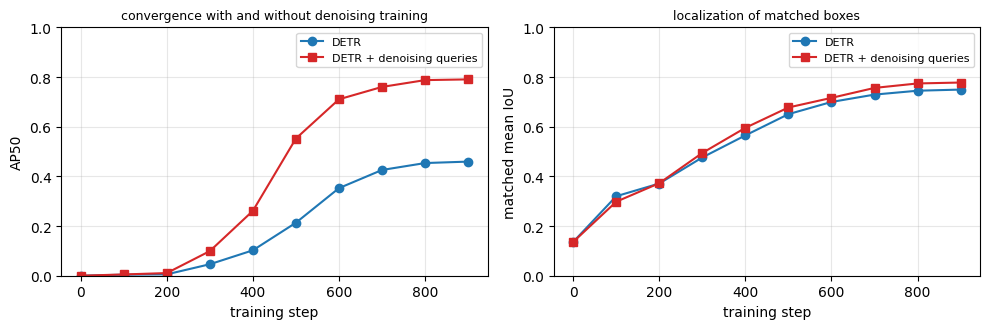

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, key, name in [(axes[0], 2, 'AP50'), (axes[1], 1, 'matched mean IoU')]:
    ax.plot([c[0] for c in curve_detr], [c[key] for c in curve_detr], 'o-', color='#1f77b4', label='DETR')
    ax.plot([c[0] for c in curve_dn], [c[key] for c in curve_dn], 's-', color='#d62728', label='DETR + denoising queries')
    ax.set_xlabel('training step'); ax.set_ylabel(name); ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_title('convergence with and without denoising training', fontsize=9)
axes[1].set_title('localization of matched boxes', fontsize=9)
plt.tight_layout(); plt.show()

Read the table and the curves together. The two models start from the same weights and see the same batches in the same order; the only difference is the extra denoising queries and their reconstruction loss. Compare the step at which each model first clears an AP50 threshold: the denoising-trained model gets there first, and its AP50 leads through the middle of training, where the plain model's matching is still flipping between queries. Two things the table also shows should be said plainly. First, in this run the denoising model's matched IoU is slightly *lower* than the plain model's at every evaluation from step 300 on (0.756 against 0.788 at step 900) while its AP50 is higher, so the gain here is in confidence and duplicate suppression rather than in localization; the audit lines at the bottom of the printout show the same thing from the side of the confident boxes. Second, the size of the gap depends on the seed and on the learning rate, so the honest claim is the one DN-DETR makes: denoising training makes the matching-based training **more stable and faster**, not that it changes what the model can eventually learn. Exercise 6 raises the learning rate to see how far that stability goes.

### 9b. Contrastive denoising: positive and negative queries

The contrastive denoising slide explains the gap left by DN-DETR:

> "DN-DETR leverages DN queries to learn predictions based on nearby ground truth boxes. However, it cannot predict 'no object' for anchors without nearby objects."

DINO uses two noise scales $\lambda_1 < \lambda_2$. **Positive queries** have noise below $\lambda_1$ and must reconstruct the box; **negative queries** have noise between $\lambda_1$ and $\lambda_2$ and must predict $\varnothing$. The model thereby learns that an anchor *slightly* off an object is still that object, while an anchor *further* off is nothing, which is exactly the distinction it needs to avoid **duplicate predictions** ("when multiple anchors are close to an object, the model may get confused on which anchor to choose") and to **reject farther anchors**. The figure draws one contrastive denoising group for a validation image: solid boxes are positives, dashed ones negatives. In our `make_dn_queries` the negatives would be a second set of slots with target label $\varnothing$; adding them is exercise 3.

5000 draws: positive |noise| per coordinate in [0.000, 0.400], negative in [0.400, 1.000]  (assert: every coordinate on its own side of lambda_1 = 0.4 PASSED)


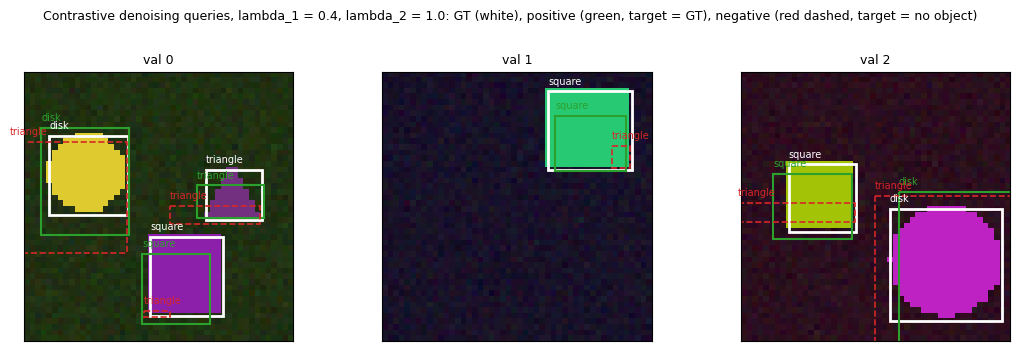

In [36]:
def cdn_noise(lam1, lam2, g):
    '''Noise for one positive and one negative query. As in DINO, sign and magnitude are drawn per coordinate:
    every coordinate of the positive has |noise| < lam1, every coordinate of the negative has lam1 <= |noise| < lam2.'''
    sign = (torch.randint(0, 2, (4,), generator=g) * 2 - 1).float()
    n_pos = sign * lam1 * torch.rand(4, generator=g)
    n_neg = sign * (lam1 + (lam2 - lam1) * torch.rand(4, generator=g))
    return n_pos, n_neg

def cdn_group(gt_boxes, lam1=0.4, lam2=1.0, seed=0):
    '''One contrastive denoising group: a positive (every coordinate's |noise| < lam1) and a negative (every coordinate's |noise| in [lam1, lam2)) query per object.'''
    g = torch.Generator().manual_seed(seed)
    pos, neg = [], []
    for b in gt_boxes:
        n_pos, n_neg = cdn_noise(lam1, lam2, g)
        for noise, store in [(n_pos, pos), (n_neg, neg)]:
            nb = b.clone(); nb[:2] += noise[:2] * b[2:] / 2; nb[2:] *= 1 + noise[2:]
            store.append(nb.clamp(0.02, 0.98))
    return torch.stack(pos), torch.stack(neg)

# check the two noise ranges on many draws: no coordinate of a positive reaches lambda_1, none of a negative falls below it
g = torch.Generator().manual_seed(0)
draws = [cdn_noise(0.4, 1.0, g) for _ in range(5000)]
P, Ng = torch.stack([d[0] for d in draws]).abs(), torch.stack([d[1] for d in draws]).abs()
assert P.max() < 0.4 and Ng.min() >= 0.4 and Ng.max() < 1.0
print(f'5000 draws: positive |noise| per coordinate in [{P.min():.3f}, {P.max():.3f}], negative in [{Ng.min():.3f}, {Ng.max():.3f}]  '
      f'(assert: every coordinate on its own side of lambda_1 = 0.4 PASSED)')

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for j, (ax, seed) in enumerate(zip(axes, [0, 1, 2])):
    pos, neg = cdn_group(Bva[j], seed=seed)
    ax.imshow(Xva[j].permute(1, 2, 0).numpy())
    draw_boxes(ax, Bva[j], Lva[j], color='white', lw=2)
    draw_boxes(ax, pos, Lva[j], color='#2ca02c', lw=1.5)
    draw_boxes(ax, neg, [NO_OBJ - 1] * len(neg), color='#d62728', ls='--', lw=1.2)
    ax.set_title(f'val {j}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Contrastive denoising queries, lambda_1 = 0.4, lambda_2 = 1.0: GT (white), positive (green, target = GT), negative (red dashed, target = no object)', y=1.02, fontsize=9)
plt.tight_layout(); plt.show()

### 9c. Mixed query selection

The mixed-query-selection slides describe three ways to initialise the decoder queries, each with a **content part** and a **positional part** (the anchor box):

| variant | positional part (anchors) | content part | used by |
|---|---|---|---|
| static queries | learned from the training data, same for every image | zero vectors (or learned) | DETR, DN-DETR |
| pure query selection | top-$K$ encoder tokens, their predicted boxes | the same top-$K$ encoder features | two-stage Deformable DETR |
| **mixed query selection** | top-$K$ encoder tokens, their predicted boxes | **learned**, same for every image | DINO |

The slide's objection to pure query selection is that "selected encoder features are preliminary content features without refinement; this can be ambiguous and misleading to the decoder". DINO keeps the image-dependent anchors, which give the decoder a good starting position, but initialises the content queries independently, so that the decoder reads the content out of the image through cross-attention rather than trusting a raw encoder token. Our tiny DETR uses static queries; the scatter plot in section 6 showed the price, each query has to cover a fixed region for every image.

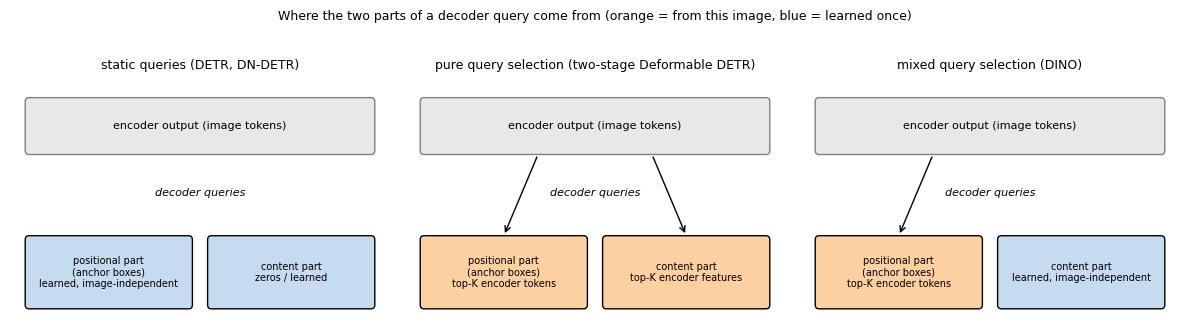

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
def box_row(ax, title, anchors, content, anchor_src, content_src):
    ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off'); ax.set_title(title, fontsize=9)
    ax.add_patch(mpatches.FancyBboxPatch((0.5, 4.2), 9, 1.2, boxstyle='round,pad=0.1', facecolor='#e8e8e8', edgecolor='gray'))
    ax.text(5, 4.8, 'encoder output (image tokens)', ha='center', va='center', fontsize=8)
    ax.add_patch(mpatches.FancyBboxPatch((0.5, 0.4), 4.2, 1.6, boxstyle='round,pad=0.1', facecolor=anchors, edgecolor='k'))
    ax.text(2.6, 1.2, f'positional part\n(anchor boxes)\n{anchor_src}', ha='center', va='center', fontsize=7)
    ax.add_patch(mpatches.FancyBboxPatch((5.3, 0.4), 4.2, 1.6, boxstyle='round,pad=0.1', facecolor=content, edgecolor='k'))
    ax.text(7.4, 1.2, f'content part\n{content_src}', ha='center', va='center', fontsize=7)
    if anchor_src.startswith('top-K'):
        ax.annotate('', xy=(2.6, 2.1), xytext=(3.5, 4.1), arrowprops=dict(arrowstyle='->', color='k'))
    if content_src.startswith('top-K'):
        ax.annotate('', xy=(7.4, 2.1), xytext=(6.5, 4.1), arrowprops=dict(arrowstyle='->', color='k'))
    ax.text(5, 3.1, 'decoder queries', ha='center', fontsize=8, style='italic')
box_row(axes[0], 'static queries (DETR, DN-DETR)', '#c6dbef', '#c6dbef', 'learned, image-independent', 'zeros / learned')
box_row(axes[1], 'pure query selection (two-stage Deformable DETR)', '#fdd0a2', '#fdd0a2', 'top-K encoder tokens', 'top-K encoder features')
box_row(axes[2], 'mixed query selection (DINO)', '#fdd0a2', '#c6dbef', 'top-K encoder tokens', 'learned, image-independent')
plt.suptitle('Where the two parts of a decoder query come from (orange = from this image, blue = learned once)', y=1.02, fontsize=9)
plt.tight_layout(); plt.show()

### 9d. Look forward twice

With iterative box refinement, layer $i$ predicts an update $\Delta b_i$ and the box becomes $b_i = \mathrm{Update}(b_{i-1}, \Delta b_i)$. Deformable DETR **detaches** $b_{i-1}$ before the update, so the auxiliary loss on $b_i$ only reaches the parameters of layer $i$: the slide calls this **look forward once**. DINO conjectures "that improved box information from a later layer could be more helpful in correcting the box prediction in its adjacent early layer", and lets the loss of layer $i+1$ also update layer $i$:

$$\Delta b_i = \mathrm{Layer}_i(b_{i-1}), \qquad b'_i = \mathrm{Update}(b_{i-1}, \Delta b_i), \qquad b_i = \mathrm{Detach}(b'_i), \qquad b_i^{\mathrm{pred}} = \mathrm{Update}(b'_{i-1}, \Delta b_i).$$

The prediction of layer $i$ is built from the **undetached** $b'_{i-1}$, so its loss flows one layer back; the *input* to the next layer is still detached, so gradients never travel more than two layers. We check this with a two-layer toy: each "layer" is a linear map with its own parameter, and we print $\partial \mathcal{L}_2 / \partial \theta_1$ under both schemes.

In [38]:
def toy_refinement(look_forward_twice):
    '''Two refinement layers on a scalar box. Returns d(loss of layer 2)/d(theta_1) and d(loss of layer 1)/d(theta_1).'''
    torch.manual_seed(0)
    theta1, theta2 = torch.tensor(0.3, requires_grad=True), torch.tensor(-0.2, requires_grad=True)
    b0, target = torch.tensor(0.1), torch.tensor(0.9)
    delta1 = theta1 * (target - b0)                                      # layer 1 proposes an update from its input
    b1_undetached = b0 + delta1
    b1 = b1_undetached.detach()                                          # the next layer's INPUT is always detached
    delta2 = theta2 * (target - b1)
    if look_forward_twice:
        b2_pred = b1_undetached + delta2                                 # prediction built on the undetached box
    else:
        b2_pred = b1 + delta2                                            # look forward once: on the detached box
    loss1, loss2 = (b1_undetached - target) ** 2, (b2_pred - target) ** 2
    g1 = torch.autograd.grad(loss1, theta1, retain_graph=True)[0]
    g2 = torch.autograd.grad(loss2, theta1, allow_unused=True)[0]
    return (0.0 if g2 is None else g2.item()), g1.item()

for lft in [False, True]:
    g2, g1 = toy_refinement(lft)
    print(f"{'look forward twice' if lft else 'look forward once '}: dL1/dtheta1 = {g1:+.4f}   dL2/dtheta1 = {g2:+.4f}")
print('\nWith look forward once the loss of layer 2 never reaches theta_1 (gradient exactly 0);')
print('with look forward twice the later, better-informed loss also corrects the earlier layer.')

look forward once : dL1/dtheta1 = -0.8960   dL2/dtheta1 = +0.0000
look forward twice: dL1/dtheta1 = -0.8960   dL2/dtheta1 = -1.0752

With look forward once the loss of layer 2 never reaches theta_1 (gradient exactly 0);
with look forward twice the later, better-informed loss also corrects the earlier layer.


## 10. Explore and verify

Everything built from scratch in this notebook was checked against an independent reference. The cell below reruns those checks in one place, then adds one more, on the trained model: on how many validation images does the Hungarian matching pair every object with a box of IoU at least $0.5$ (localization is solved), and on how many of those does the model also fire exactly as many confident boxes as there are objects (the set prediction is clean, with no duplicate and no miss)? The gap between the two counts is the duplicate problem of section 5 seen from the matching side.

In [39]:
set_seed(0)
a = box_cxcywh_to_xyxy(torch.rand(8, 4) * 0.5 + 0.25); b = box_cxcywh_to_xyxy(torch.rand(5, 4) * 0.5 + 0.25)
assert torch.allclose(giou_scratch(a, b), generalized_box_iou(a, b), atol=1e-6)
assert torch.allclose(iou_scratch(a, b)[0], box_iou(a, b), atol=1e-6)
print('1. GIoU and IoU from scratch == torchvision.ops                      PASSED')
assert torch.allclose(sine_pos_2d(6, 9, 32), sine_pos_2d_loop(6, 9, 32), atol=1e-5)
print('2. vectorised 2D sinusoidal encoding == entry-by-entry formula       PASSED')
assert torch.allclose(out_ref, out_mine, atol=1e-5)
print('3. EncLayer == nn.TransformerEncoderLayer with copied weights         PASSED')
Cm = match_cost(torch.rand(6, K + 1).softmax(-1), torch.rand(6, 4) * 0.5 + 0.25, torch.tensor([1, 2, 0]), torch.rand(3, 4) * 0.5 + 0.25)
r, c = linear_sum_assignment(Cm.numpy())
assert abs(Cm[r, c].sum().item() - brute_force_match(Cm)[1]) < 1e-5
print('4. Hungarian assignment (scipy) == brute force over all assignments   PASSED')
assert torch.allclose(loss, loss_p, atol=1e-5)
print('5. Hungarian loss is invariant to permuting the predictions           PASSED')
assert torch.allclose(sample_points(feat, pts), bilinear_scratch(feat, pts), atol=1e-5)
print('6. F.grid_sample == bilinear interpolation by hand                    PASSED')
assert abs(average_precision([(0.9, 1), (0.8, 0), (0.7, 1)], 2) - (0.5 + 0.5 * 2 / 3)) < 1e-9
print('7. average precision == hand-computed example                         PASSED')

# the trained model: on how many val images is the matching a clean one-to-one with IoU >= 0.5 on every object?
with torch.no_grad():
    logits_va, boxes_va_ = detr.eval()(Xva.to(device))[-1]; detr.train()
idx_va = hungarian_match(logits_va, boxes_va_, [l.to(device) for l in Lva], [b.to(device) for b in Bva])
localized, clean = 0, 0
for i, (r, c) in enumerate(idx_va):
    iou = torch.diag(box_iou(box_cxcywh_to_xyxy(boxes_va_[i, r]), box_cxcywh_to_xyxy(Bva[i].to(device)[c])))
    n_conf = int((logits_va[i].softmax(-1)[:, :K].max(-1).values > 0.5).sum())
    localized += int((iou >= 0.5).all())
    clean += int((iou >= 0.5).all() and n_conf == len(Bva[i]))
print(f'\ntrained DETR: on {localized} of {len(Xva)} val images every object is matched with IoU >= 0.5;')
print(f'              on {clean} of those the number of confident boxes also equals the number of objects (no duplicate, no miss)')

1. GIoU and IoU from scratch == torchvision.ops                      PASSED
2. vectorised 2D sinusoidal encoding == entry-by-entry formula       PASSED
3. EncLayer == nn.TransformerEncoderLayer with copied weights         PASSED
4. Hungarian assignment (scipy) == brute force over all assignments   PASSED
5. Hungarian loss is invariant to permuting the predictions           PASSED
6. F.grid_sample == bilinear interpolation by hand                    PASSED
7. average precision == hand-computed example                         PASSED



trained DETR: on 168 of 200 val images every object is matched with IoU >= 0.5;
              on 48 of those the number of confident boxes also equals the number of objects (no duplicate, no miss)


### The static sweep: predictions through training

The four fixed validation images at each evaluation step, for the plain DETR (top row) and the denoising-trained model (bottom row). Early on neither model fires anything above the confidence threshold; then several queries fire at once around the object, and as training goes on the boxes tighten and the duplicates thin out. Compare the two rows at the same step to see which model gets there first.

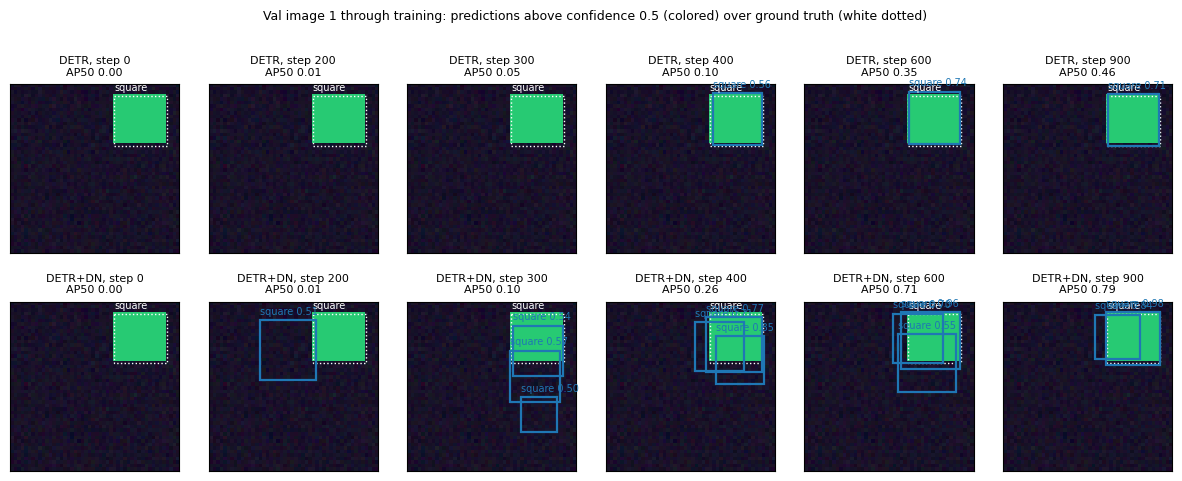

In [40]:
snap_steps = sorted(snaps_detr.keys())
show_steps = [s for s in snap_steps if s in {0, EVAL_EVERY * 2, EVAL_EVERY * 3, EVAL_EVERY * 4, EVAL_EVERY * 6, STEPS}]
img = 1
fig, axes = plt.subplots(2, len(show_steps), figsize=(12, 5.0))
for j, s in enumerate(show_steps):
    for row, (snaps, curve, name) in enumerate([(snaps_detr, curve_detr, 'DETR'), (snaps_dn, curve_dn, 'DETR+DN')]):
        ax = axes[row, j]
        ax.imshow(Xva[img].permute(1, 2, 0).numpy())
        draw_boxes(ax, Bva[img], Lva[img], color='white', ls=':', lw=1)
        draw_boxes(ax, *snaps[s][SNAP_IMAGES.index(img)])
        ap = dict((c[0], c[2]) for c in curve)[s]
        ax.set_title(f'{name}, step {s}\nAP50 {ap:.2f}', fontsize=8); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f'Val image {img} through training: predictions above confidence 0.5 (colored) over ground truth (white dotted)', y=1.0, fontsize=9)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

### Widget 6: the training scrubber

`step` scrubs through the evaluation snapshots of both models on the chosen `image`; the snapshots were stored during training, so nothing is recomputed. Watch for the moment the first confident box appears, and compare at which step each model gets all objects right.

In [41]:
def training_scrubber(step=0, image=0):
    k = SNAP_IMAGES.index(image)
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
    for ax, (snaps, curve, name) in zip(axes[:2], [(snaps_detr, curve_detr, 'DETR'), (snaps_dn, curve_dn, 'DETR + denoising')]):
        ax.imshow(Xva[image].permute(1, 2, 0).numpy())
        draw_boxes(ax, Bva[image], Lva[image], color='white', ls=':', lw=1)
        draw_boxes(ax, *snaps[step][k])
        ap = dict((c[0], c[2]) for c in curve)[step]
        ax.set_title(f'{name} at step {step}: {len(snaps[step][k][0])} detections, val AP50 {ap:.2f}', fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    axes[2].plot([c[0] for c in curve_detr], [c[2] for c in curve_detr], 'o-', color='#1f77b4', label='DETR')
    axes[2].plot([c[0] for c in curve_dn], [c[2] for c in curve_dn], 's-', color='#d62728', label='DETR + DN')
    axes[2].axvline(step, color='gray', ls=':'); axes[2].set_ylim(0, 1); axes[2].set_xlabel('step'); axes[2].set_ylabel('val AP50'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(training_scrubber,
         step=widgets.SelectionSlider(options=snap_steps, value=snap_steps[0], description='step', continuous_update=False),
         image=Dropdown(options=SNAP_IMAGES, value=0, description='image'));

interactive(children=(SelectionSlider(continuous_update=False, description='step', options=(0, 100, 200, 300, …

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Set prediction** | DETR predicts a fixed set of $N$ slots in parallel, each a class (including $\varnothing$) and a box; there are no anchors and no NMS; the loss matches one prediction per object and trains the rest toward $\varnothing$, and together with the self-attention among queries that is all that suppresses duplicates. |
| **Generalized IoU** | $\mathrm{GIoU} = \mathrm{IoU} - \lvert C \setminus (A \cup B)\rvert / \lvert C \rvert$ is scale-invariant (the same 20% shift costs the same at every box size, unlike $L_1$) and keeps a gradient when boxes do not overlap. |
| **Bipartite matching** | The ground truth is padded with $\varnothing$ to size $N$ and $\hat\sigma$ minimises $\sum_i \mathcal{L}_{\mathrm{match}}$; brute force is $O(N!)$, the Hungarian algorithm $O(N^3)$, and on our tiny case they agree exactly. |
| **Hungarian loss** | Cross-entropy on every slot (with $\varnothing$ down-weighted by 0.1) plus $L_1$ and GIoU on the matched pairs; it is a set loss, invariant to permuting the predictions, and is applied to every decoder layer. |
| **Object queries** | Learned embeddings that specialise by region and size through the matching alone; the decoder cross-attention shows each firing query reading the tokens of its object. |
| **DETR's limitations** | Dense attention time grows almost quadratically in the token count once the maps are large enough to fill the CPU (slope near 2 between the two largest maps); attention at initialization is near-uniform ($1/N_k$), so training is slow; small objects score lower than large ones. |
| **Deformable attention** | Each query samples $K$ points at learned offsets around a reference point, with attention weights predicted directly from the query: cost $O(2N_q C^2 + \min(HWC^2, N_qKC^2))$, linear in $HW$, and multi-scale for free. |
| **Denoising training** | Noisy ground-truth boxes are fed as extra queries that must reconstruct the clean boxes without matching, behind an attention mask; a stable auxiliary task that speeds up convergence. |
| **DINO** | Contrastive denoising (positives reconstruct, negatives predict $\varnothing$), mixed query selection (image-dependent anchors, learned content) and look forward twice (the loss of layer $i+1$ also updates layer $i$). |

### The three detectors at a glance

| | DETR (ECCV 2020) | Deformable DETR (ICLR 2021) | DINO (ICLR 2023) |
|---|---|---|---|
| attention | dense, all tokens | deformable, $K$ sampled points, multi-scale | deformable, multi-scale |
| queries | static learned embeddings | learned, or top-$K$ encoder proposals (two-stage) | mixed: top-$K$ anchors, learned content |
| box prediction | direct from each layer | iterative refinement, detached between layers | iterative refinement, look forward twice |
| training signal | Hungarian loss | Hungarian loss | Hungarian loss plus contrastive denoising queries |
| encoder cost in $HW$ | quadratic | linear | linear |
| COCO schedule | 500 epochs | 50 epochs | 12 to 36 epochs |

## Exercises

1. **The slide's question, on your own model.** The deck asks "How can we reduce the quadratic computational complexity of self-attention?" Replace the two `EncLayer`s of `TinyDETR` with encoder layers built on `DeformAttn` (every pixel is a query with its own reference point, as in section 8a), retrain with `DetrTrainer`, and report AP50 and the training time against the dense model. Then raise the image size to $96 \times 96$ (stride 4 gives 576 tokens) and repeat the timing of section 7a for both encoders.

2. **The no-object weight.** `hungarian_loss` down-weights the $\varnothing$ class with `eos_coef=0.1`. Retrain the tiny DETR with `eos_coef` in $\{1.0, 0.1, 0.01\}$ and report AP50 and the mean number of confident detections per image at the end. Which value produces duplicate detections, and which produces missed objects? *With the default 0.1 our model fires more confident boxes than there are objects and the audit in section 5 attributes a good share of them to duplicates; the counts in section 10 show on how many images the set came out clean.*

3. **Contrastive denoising.** Extend `make_dn_queries` with a second set of slots per group whose boxes carry noise between $\lambda_1 = 0.4$ and $\lambda_2 = 1.0$ (use `cdn_group` from section 9b) and whose `clean_labels` are $\varnothing$; keep the box loss off for those slots. Retrain and compare the AP50 curve with the denoising-only run of section 9a.

4. **Number of queries, measured.** Section 3c showed the fraction of $\varnothing$ slots as a function of $N$. Now train `TinyDETR(n_queries=N)` for $N \in \{3, 6, 12, 24\}$ with the same budget and report AP50. Does a model with $N = 3$ ever detect three objects reliably, and does a large $N$ cost accuracy or only time?

5. **Iterative box refinement.** Make each decoder layer predict a box *update* on top of the previous layer's box (inverse-sigmoid space, as in Deformable DETR), first with the previous box detached (look forward once) and then with DINO's look forward twice from section 9d. Report AP50 at steps 200, 400 and the end for both, and check which one reaches AP50 $\ge 0.5$ first.

6. **A learning-rate stress test.** Section 9a compared the two models at the peak learning rate $10^{-3}$. Retrain both with `DetrTrainer(TinyDETR(), STEPS, lr=3e-3)` and `DetrTrainer(TinyDETR(), STEPS, lr=3e-3, use_dn=True)` (calling `run` in two halves as above) and report the AP50 curves. Does the plain model still train at this learning rate, and does the denoising task change that? *In our own run at this learning rate the plain model stalled (AP50 0.02 after 900 steps, matched IoU 0.39) while the denoising-trained model reached AP50 0.92; check whether your run agrees.*